Partha Pratim Ray, Sikkim University, India, parthapratimray1986[at]gmail.com

In [1]:
# ============================================================
# STEP 1: Imports
# ============================================================

from __future__ import annotations

import os
import textwrap
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception as exc:  # pragma: no cover
    raise ImportError("Please install scipy using: pip install scipy") from exc

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
    multipletests = None

warnings.filterwarnings("ignore", category=RuntimeWarning)


# ============================================================
# STEP 2: User configuration
# ============================================================

INPUT_CSV_PATH = Path(r"D:\technical writing\evapogpt\results.csv")
OUTPUT_DIR = INPUT_CSV_PATH.parent / "evapogpt_publication_analysis_outputs"

# Main latency metrics requested by the user.
DELAY_METRICS: List[str] = [
    "openai_interpretation_delay_sec",
    "geocoding_api_delay_sec",
    "open_meteo_weather_api_delay_sec",
    "local_processing_delay_sec",
    "chart_generation_delay_sec",
    "openai_report_generation_delay_sec",
    "network_delay_sec",
    "total_delay_sec",
]

# Component metrics used for within-run comparison. total_delay_sec is excluded
# because it is the aggregate outcome, not an individual processing component.
COMPONENT_DELAY_METRICS: List[str] = [
    "openai_interpretation_delay_sec",
    "geocoding_api_delay_sec",
    "open_meteo_weather_api_delay_sec",
    "local_processing_delay_sec",
    "chart_generation_delay_sec",
    "openai_report_generation_delay_sec",
]

# Evapotranspiration/agrometeorological variables, analysed if present.
AGRO_METRICS: List[str] = [
    "actual_evapotranspiration_total_mm",
    "et0_fao_total_mm_from_hourly",
    "precipitation_total_mm",
    "temperature_mean_c",
    "relative_humidity_mean_percent",
    "wind_speed_mean_kmh",
    "vapour_pressure_deficit_mean_kpa",
    "shortwave_radiation_mean_wm2",
]

# Matplotlib export settings.
FIG_DPI = 300
FIG_FORMATS = ["png", "pdf"]



In [2]:
# ============================================================
# STEP 3: Utility functions
# ============================================================

def ensure_output_dirs(base_dir: Path) -> Dict[str, Path]:
    """Create output folders."""

    dirs = {
        "base": base_dir,
        "figures": base_dir / "figures",
        "tables": base_dir / "tables",
        "statistics": base_dir / "statistics",
    }

    for folder in dirs.values():
        folder.mkdir(parents=True, exist_ok=True)

    return dirs


def save_figure(fig: plt.Figure, output_path_without_ext: Path) -> None:
    """Save a figure in multiple publication-friendly formats."""

    for ext in FIG_FORMATS:
        fig.savefig(
            output_path_without_ext.with_suffix(f".{ext}"),
            dpi=FIG_DPI,
            bbox_inches="tight"
        )


def print_section(title: str) -> None:
    """Print a clear console section heading."""

    rule = "=" * len(title)
    print(f"\n{rule}\n{title}\n{rule}")


def print_copyable_table(df: pd.DataFrame, title: str, max_rows: Optional[int] = None) -> None:
    """Print a table in both Markdown and CSV-friendly style."""

    print_section(title)

    table_to_print = df.copy()
    if max_rows is not None:
        table_to_print = table_to_print.head(max_rows)

    try:
        print("\nMarkdown table:\n")
        print(table_to_print.to_markdown(index=False))
    except Exception:
        print("\nPlain table:\n")
        print(table_to_print.to_string(index=False))

    print("\nCSV-copyable table:\n")
    print(table_to_print.to_csv(index=False))


def save_table(df: pd.DataFrame, path_without_ext: Path) -> None:
    """Save a dataframe as CSV, Markdown, and LaTeX."""

    df.to_csv(path_without_ext.with_suffix(".csv"), index=False, encoding="utf-8-sig")

    try:
        path_without_ext.with_suffix(".md").write_text(
            df.to_markdown(index=False),
            encoding="utf-8"
        )
    except Exception:
        pass

    try:
        path_without_ext.with_suffix(".tex").write_text(
            df.to_latex(index=False, escape=False),
            encoding="utf-8"
        )
    except Exception:
        pass


def coerce_numeric_columns(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """Convert selected columns to numeric when present."""

    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def clean_metric_name(name: str) -> str:
    """Readable label for figures and tables."""

    replacements = {
        "openai": "OpenAI",
        "api": "API",
        "sec": "s",
        "et0": "ET0",
        "fao": "FAO",
        "mm": "mm",
        "kpa": "kPa",
        "wm2": "W/m²",
    }

    label = name.replace("_", " ")
    for old, new in replacements.items():
        label = label.replace(old, new)
    return label.title().replace("Api", "API").replace("Openai", "OpenAI")


def stars_from_p(p: float) -> str:
    """Return significance stars."""

    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def holm_adjust(p_values: List[float]) -> List[float]:
    """Holm correction using statsmodels if available; otherwise fallback."""

    arr = np.array(p_values, dtype=float)

    if HAS_STATSMODELS:
        return multipletests(arr, method="holm")[1].tolist()

    # Manual Holm-Bonferroni adjusted p-values.
    order = np.argsort(arr)
    adjusted = np.empty_like(arr)
    m = len(arr)
    running_max = 0.0

    for rank, idx in enumerate(order):
        adj = (m - rank) * arr[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)

    return adjusted.tolist()


In [3]:
# ============================================================
# STEP 4: Data loading and validation
# ============================================================

def load_results(csv_path: Path) -> pd.DataFrame:
    """Load the EvapoGPT results CSV."""

    if not csv_path.exists():
        raise FileNotFoundError(
            f"CSV file not found: {csv_path}\n"
            "Please check INPUT_CSV_PATH at the top of the script."
        )

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    all_numeric = list(dict.fromkeys(DELAY_METRICS + AGRO_METRICS))
    df = coerce_numeric_columns(df, all_numeric)

    if "run_timestamp" in df.columns:
        df["run_timestamp"] = pd.to_datetime(df["run_timestamp"], errors="coerce")

    if "place" not in df.columns and "parsed_place" in df.columns:
        df["place"] = df["parsed_place"]

    if "place" not in df.columns:
        df["place"] = [f"Run {i + 1}" for i in range(len(df))]

    # Preserve original order for run-wise plots.
    df["run_order"] = np.arange(1, len(df) + 1)

    return df


def validate_required_metrics(df: pd.DataFrame) -> List[str]:
    """Return delay metrics available in the CSV."""

    available = [m for m in DELAY_METRICS if m in df.columns]
    missing = [m for m in DELAY_METRICS if m not in df.columns]

    if missing:
        print_section("Warning: Missing Requested Metrics")
        print("The following requested metrics were not found in the CSV:")
        for m in missing:
            print(f"- {m}")

    if not available:
        raise ValueError("None of the requested delay metrics were found in the CSV.")

    return available

In [4]:
# ============================================================
# STEP 5: Descriptive summaries
# ============================================================

def descriptive_statistics(df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    """Compute publication-ready descriptive statistics."""

    rows = []
    for metric in metrics:
        series = df[metric].dropna()
        if series.empty:
            continue

        rows.append({
            "Metric": clean_metric_name(metric),
            "Column": metric,
            "N": int(series.count()),
            "Mean": series.mean(),
            "SD": series.std(ddof=1),
            "Median": series.median(),
            "IQR": series.quantile(0.75) - series.quantile(0.25),
            "Min": series.min(),
            "Q1": series.quantile(0.25),
            "Q3": series.quantile(0.75),
            "Max": series.max(),
            "CV_percent": (series.std(ddof=1) / series.mean() * 100) if series.mean() != 0 else np.nan,
        })

    out = pd.DataFrame(rows)
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(6)
    return out


def contribution_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Compute percentage contribution of latency components to total delay."""

    required = [m for m in COMPONENT_DELAY_METRICS if m in df.columns]
    if "total_delay_sec" not in df.columns or not required:
        return pd.DataFrame()

    rows = []
    for metric in required:
        valid = df[[metric, "total_delay_sec"]].dropna()
        valid = valid[valid["total_delay_sec"] > 0]
        if valid.empty:
            continue
        percent = valid[metric] / valid["total_delay_sec"] * 100
        rows.append({
            "Latency Component": clean_metric_name(metric),
            "Column": metric,
            "Mean Contribution (%)": percent.mean(),
            "Median Contribution (%)": percent.median(),
            "SD Contribution (%)": percent.std(ddof=1),
            "Min Contribution (%)": percent.min(),
            "Max Contribution (%)": percent.max(),
        })

    out = pd.DataFrame(rows)
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(6)
    return out.sort_values("Mean Contribution (%)", ascending=False)


In [5]:
# ============================================================
# STEP 6: Statistical testing
# ============================================================

def normality_tests(df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    """Run Shapiro-Wilk normality tests for each metric."""

    rows = []
    for metric in metrics:
        x = df[metric].dropna()
        if len(x) < 3:
            rows.append({
                "Metric": clean_metric_name(metric),
                "Column": metric,
                "N": len(x),
                "Test": "Shapiro-Wilk",
                "Statistic": np.nan,
                "p_value": np.nan,
                "Interpretation": "Insufficient sample size",
            })
            continue

        stat, p_value = stats.shapiro(x)
        rows.append({
            "Metric": clean_metric_name(metric),
            "Column": metric,
            "N": len(x),
            "Test": "Shapiro-Wilk",
            "Statistic": stat,
            "p_value": p_value,
            "Interpretation": "Approximately normal" if p_value >= 0.05 else "Non-normal distribution",
        })

    out = pd.DataFrame(rows)
    for col in ["Statistic", "p_value"]:
        if col in out.columns:
            out[col] = out[col].round(6)
    return out


def friedman_test_components(df: pd.DataFrame) -> pd.DataFrame:
    """Compare repeated latency components within the same EvapoGPT runs."""

    metrics = [m for m in COMPONENT_DELAY_METRICS if m in df.columns]
    complete = df[metrics].dropna()

    if len(metrics) < 3 or complete.shape[0] < 2:
        return pd.DataFrame([{
            "Test": "Friedman repeated-measures test",
            "N_complete_runs": int(complete.shape[0]),
            "K_components": len(metrics),
            "Statistic": np.nan,
            "p_value": np.nan,
            "Interpretation": "Insufficient data for Friedman test",
        }])

    stat, p_value = stats.friedmanchisquare(*[complete[m].values for m in metrics])

    return pd.DataFrame([{
        "Test": "Friedman repeated-measures test",
        "N_complete_runs": int(complete.shape[0]),
        "K_components": len(metrics),
        "Statistic": round(stat, 6),
        "p_value": round(p_value, 6),
        "Interpretation": (
            "Latency components differ significantly"
            if p_value < 0.05 else
            "No statistically significant difference among latency components"
        ),
    }])


def wilcoxon_posthoc_components(df: pd.DataFrame) -> pd.DataFrame:
    """Pairwise Wilcoxon signed-rank tests among latency components."""

    metrics = [m for m in COMPONENT_DELAY_METRICS if m in df.columns]
    complete = df[metrics].dropna()

    rows = []
    p_values = []

    for i in range(len(metrics)):
        for j in range(i + 1, len(metrics)):
            a, b = metrics[i], metrics[j]
            x = complete[a]
            y = complete[b]

            if len(x) < 2 or np.allclose(x, y, equal_nan=True):
                stat, p_value = np.nan, np.nan
            else:
                try:
                    stat, p_value = stats.wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
                except Exception:
                    stat, p_value = np.nan, np.nan

            rows.append({
                "Component A": clean_metric_name(a),
                "Column A": a,
                "Component B": clean_metric_name(b),
                "Column B": b,
                "N_complete_pairs": int(len(x)),
                "Wilcoxon Statistic": stat,
                "p_value_raw": p_value,
                "Median A": x.median() if len(x) else np.nan,
                "Median B": y.median() if len(y) else np.nan,
                "Median Difference A_minus_B": (x - y).median() if len(x) else np.nan,
            })
            p_values.append(p_value)

    out = pd.DataFrame(rows)
    valid_mask = out["p_value_raw"].notna()

    out["p_value_holm"] = np.nan
    if valid_mask.any():
        adjusted = holm_adjust(out.loc[valid_mask, "p_value_raw"].tolist())
        out.loc[valid_mask, "p_value_holm"] = adjusted

    out["Significance"] = out["p_value_holm"].apply(stars_from_p)

    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(6)

    return out


def kruskal_components_as_independent(df: pd.DataFrame) -> pd.DataFrame:
    """
    Non-parametric omnibus test across latency components.

    Note: Friedman is more appropriate because the same runs contribute multiple
    component delays. Kruskal-Wallis is reported only as a supplementary view.
    """

    metrics = [m for m in COMPONENT_DELAY_METRICS if m in df.columns]
    arrays = [df[m].dropna().values for m in metrics if len(df[m].dropna()) > 0]

    if len(arrays) < 2:
        return pd.DataFrame([{
            "Test": "Kruskal-Wallis supplementary test",
            "Statistic": np.nan,
            "p_value": np.nan,
            "Interpretation": "Insufficient data",
            "Note": "Friedman is preferred for repeated-measures latency components.",
        }])

    stat, p_value = stats.kruskal(*arrays)

    return pd.DataFrame([{
        "Test": "Kruskal-Wallis supplementary test",
        "Statistic": round(stat, 6),
        "p_value": round(p_value, 6),
        "Interpretation": (
            "At least one latency component differs"
            if p_value < 0.05 else
            "No statistically significant difference among components"
        ),
        "Note": "Friedman is preferred for repeated-measures latency components.",
    }])


def spearman_correlations(df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    """Compute Spearman correlation of each metric with total delay."""

    if "total_delay_sec" not in df.columns:
        return pd.DataFrame()

    rows = []
    for metric in metrics:
        if metric == "total_delay_sec" or metric not in df.columns:
            continue
        valid = df[[metric, "total_delay_sec"]].dropna()
        if len(valid) < 3:
            continue
        rho, p_value = stats.spearmanr(valid[metric], valid["total_delay_sec"])
        rows.append({
            "Metric": clean_metric_name(metric),
            "Column": metric,
            "N": len(valid),
            "Spearman rho with total_delay_sec": rho,
            "p_value": p_value,
            "Significance": stars_from_p(p_value),
        })

    out = pd.DataFrame(rows)
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(6)
    return out.sort_values("Spearman rho with total_delay_sec", ascending=False)


def pearson_correlation_matrix(df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    """Generate a correlation matrix for available delay metrics."""

    available = [m for m in metrics if m in df.columns]
    corr = df[available].corr(method="pearson")
    corr.index = [clean_metric_name(x) for x in corr.index]
    corr.columns = [clean_metric_name(x) for x in corr.columns]
    return corr.round(3)


def optional_place_group_tests(df: pd.DataFrame) -> pd.DataFrame:
    """
    Test total delay across location groups only if groups have replication.
    With one run per place, this test is not meaningful.
    """

    if "place" not in df.columns or "total_delay_sec" not in df.columns:
        return pd.DataFrame()

    group_counts = df.groupby("place")["total_delay_sec"].count()
    replicated_groups = group_counts[group_counts >= 2].index.tolist()

    if len(replicated_groups) < 2:
        return pd.DataFrame([{
            "Test": "Kruskal-Wallis across places",
            "Statistic": np.nan,
            "p_value": np.nan,
            "Interpretation": "Not performed: at least two places require two or more runs each.",
        }])

    arrays = [df.loc[df["place"] == place, "total_delay_sec"].dropna().values for place in replicated_groups]
    stat, p_value = stats.kruskal(*arrays)

    return pd.DataFrame([{
        "Test": "Kruskal-Wallis across places",
        "Statistic": round(stat, 6),
        "p_value": round(p_value, 6),
        "Interpretation": "Significant place-wise difference" if p_value < 0.05 else "No significant place-wise difference",
    }])


In [6]:
# ============================================================
# STEP 7: Plotting functions
# ============================================================

def add_table_below_axis(fig: plt.Figure, ax: plt.Axes, table_df: pd.DataFrame, max_rows: int = 8) -> None:
    """
    Place a compact copyable-style table below a plot.

    For full copyable data, this script also prints and saves CSV/Markdown tables.
    The plot table is intentionally compact to avoid overcrowding figures.
    """

    if table_df.empty:
        return

    small = table_df.head(max_rows).copy()

    # Convert all values to compact strings for visual table.
    for col in small.columns:
        if pd.api.types.is_numeric_dtype(small[col]):
            small[col] = small[col].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
        else:
            small[col] = small[col].astype(str).map(lambda x: textwrap.shorten(x, width=28, placeholder="…"))

    table = ax.table(
        cellText=small.values,
        colLabels=small.columns,
        cellLoc="center",
        colLoc="center",
        loc="bottom",
        bbox=[0.0, -0.62, 1.0, 0.42]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.2)

    plt.subplots_adjust(bottom=0.34)


def plot_ranked_total_delay(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Bar plot ranking total delay by location/run."""

    if "total_delay_sec" not in df.columns:
        return pd.DataFrame()

    plot_df = df[["run_order", "place", "total_delay_sec"]].dropna().copy()
    plot_df = plot_df.sort_values("total_delay_sec", ascending=False)
    plot_df["Place / Run"] = plot_df["place"].astype(str) + " (Run " + plot_df["run_order"].astype(str) + ")"

    fig, ax = plt.subplots(figsize=(12, 6.8))
    ax.bar(plot_df["Place / Run"], plot_df["total_delay_sec"])
    ax.set_title("Ranked Total Execution Delay Across EvapoGPT Runs", fontweight="bold", fontsize=14)
    ax.set_xlabel("Location / Run")
    ax.set_ylabel("Total delay (seconds)")
    ax.tick_params(axis="x", rotation=70)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    for idx, value in enumerate(plot_df["total_delay_sec"]):
        ax.text(idx, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8, rotation=0)

    table_df = plot_df[["Place / Run", "total_delay_sec"]].rename(columns={"total_delay_sec": "Total Delay (s)"})
    add_table_below_axis(fig, ax, table_df, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_01_ranked_total_delay")
    plt.close(fig)

    return table_df


def plot_latency_component_means(desc_df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Mean latency by component with error bars."""

    comp_names = [clean_metric_name(m) for m in COMPONENT_DELAY_METRICS]
    comp_desc = desc_df[desc_df["Metric"].isin(comp_names)].copy()
    if comp_desc.empty:
        return pd.DataFrame()

    comp_desc = comp_desc.sort_values("Mean", ascending=False)

    fig, ax = plt.subplots(figsize=(11, 6.5))
    x = np.arange(len(comp_desc))
    ax.bar(x, comp_desc["Mean"], yerr=comp_desc["SD"], capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_desc["Metric"], rotation=45, ha="right")
    ax.set_title("Mean Latency of EvapoGPT Processing Components", fontweight="bold", fontsize=14)
    ax.set_ylabel("Delay (seconds)")
    ax.set_xlabel("Processing component")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    for i, value in enumerate(comp_desc["Mean"]):
        ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

    table_df = comp_desc[["Metric", "N", "Mean", "SD", "Median", "IQR"]]
    add_table_below_axis(fig, ax, table_df, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_02_latency_component_means")
    plt.close(fig)

    return table_df


def plot_stacked_latency_by_run(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Stacked bar plot of latency components by run."""

    metrics = [m for m in COMPONENT_DELAY_METRICS if m in df.columns]
    if not metrics:
        return pd.DataFrame()

    plot_df = df[["run_order", "place"] + metrics].dropna(subset=metrics, how="all").copy()
    plot_df["Run Label"] = plot_df["run_order"].astype(str) + ": " + plot_df["place"].astype(str)

    fig, ax = plt.subplots(figsize=(13, 7))
    bottom = np.zeros(len(plot_df))
    x = np.arange(len(plot_df))

    for metric in metrics:
        values = plot_df[metric].fillna(0).values
        ax.bar(x, values, bottom=bottom, label=clean_metric_name(metric))
        bottom += values

    ax.set_title("Stacked Latency Composition Across EvapoGPT Runs", fontweight="bold", fontsize=14)
    ax.set_xlabel("Run and location")
    ax.set_ylabel("Delay (seconds)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["Run Label"], rotation=70, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

    compact = plot_df[["Run Label"] + metrics].copy()
    compact.columns = ["Run Label"] + [clean_metric_name(m) for m in metrics]
    add_table_below_axis(fig, ax, compact, max_rows=5)

    save_figure(fig, dirs["figures"] / "figure_03_stacked_latency_by_run")
    plt.close(fig)

    return compact


def plot_latency_boxplot(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Boxplot of latency metric distributions."""

    metrics = [m for m in DELAY_METRICS if m in df.columns]
    if not metrics:
        return pd.DataFrame()

    long_df = df[metrics].melt(var_name="Metric", value_name="Delay (s)").dropna()
    long_df["Metric Label"] = long_df["Metric"].map(clean_metric_name)

    ordered_labels = (
        long_df.groupby("Metric Label")["Delay (s)"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    data = [long_df.loc[long_df["Metric Label"] == label, "Delay (s)"].values for label in ordered_labels]

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.boxplot(data, labels=ordered_labels, showmeans=True)
    ax.set_title("Distribution of EvapoGPT Latency Metrics", fontweight="bold", fontsize=14)
    ax.set_xlabel("Latency metric")
    ax.set_ylabel("Delay (seconds)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    summary = (
        long_df.groupby("Metric Label")["Delay (s)"]
        .agg(N="count", Median="median", IQR=lambda x: x.quantile(0.75) - x.quantile(0.25))
        .reset_index()
        .sort_values("Median", ascending=False)
    )
    add_table_below_axis(fig, ax, summary, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_04_latency_boxplot")
    plt.close(fig)

    return summary


def plot_contribution_pie_and_bar(contrib_df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Plot average contribution of components to total delay."""

    if contrib_df.empty:
        return pd.DataFrame()

    fig, ax = plt.subplots(figsize=(11, 6.2))
    ax.bar(contrib_df["Latency Component"], contrib_df["Mean Contribution (%)"])
    ax.set_title("Average Contribution of Processing Components to Total Delay", fontweight="bold", fontsize=14)
    ax.set_xlabel("Processing component")
    ax.set_ylabel("Mean contribution to total delay (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    for idx, value in enumerate(contrib_df["Mean Contribution (%)"]):
        ax.text(idx, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=8)

    table_df = contrib_df[["Latency Component", "Mean Contribution (%)", "Median Contribution (%)"]]
    add_table_below_axis(fig, ax, table_df, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_05_latency_contribution")
    plt.close(fig)

    return table_df


def plot_correlation_heatmap(corr_df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Plot correlation matrix heatmap using matplotlib only."""

    if corr_df.empty:
        return pd.DataFrame()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_df.values, aspect="auto", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")

    ax.set_xticks(np.arange(corr_df.shape[1]))
    ax.set_yticks(np.arange(corr_df.shape[0]))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title("Correlation Matrix of EvapoGPT Latency Metrics", fontweight="bold", fontsize=14)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    save_figure(fig, dirs["figures"] / "figure_06_latency_correlation_heatmap")
    plt.close(fig)

    return corr_df.reset_index().rename(columns={"index": "Metric"})


def plot_total_delay_vs_report_delay(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Scatter plot for OpenAI report delay versus total delay."""

    x_col = "openai_report_generation_delay_sec"
    y_col = "total_delay_sec"
    if x_col not in df.columns or y_col not in df.columns:
        return pd.DataFrame()

    plot_df = df[["place", x_col, y_col]].dropna().copy()
    if plot_df.empty:
        return pd.DataFrame()

    fig, ax = plt.subplots(figsize=(9, 6.5))
    ax.scatter(plot_df[x_col], plot_df[y_col], s=60, alpha=0.8)

    if len(plot_df) >= 2:
        slope, intercept = np.polyfit(plot_df[x_col], plot_df[y_col], 1)
        xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
        ax.plot(xs, slope * xs + intercept, linewidth=2)

    for _, row in plot_df.iterrows():
        ax.annotate(
            textwrap.shorten(str(row["place"]), width=18, placeholder="…"),
            (row[x_col], row[y_col]),
            fontsize=7,
            xytext=(4, 4),
            textcoords="offset points"
        )

    ax.set_title("Relationship Between GPT Report Generation Delay and Total Delay", fontweight="bold", fontsize=14)
    ax.set_xlabel("OpenAI report generation delay (seconds)")
    ax.set_ylabel("Total delay (seconds)")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    table_df = plot_df.rename(columns={
        "place": "Place",
        x_col: "OpenAI Report Delay (s)",
        y_col: "Total Delay (s)",
    }).sort_values("Total Delay (s)", ascending=False)
    add_table_below_axis(fig, ax, table_df, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_07_total_vs_report_delay")
    plt.close(fig)

    return table_df


def plot_agro_evapotranspiration(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Plot actual ET and FAO ET0 by location if available."""

    required = ["actual_evapotranspiration_total_mm", "et0_fao_total_mm_from_hourly"]
    if not all(col in df.columns for col in required):
        return pd.DataFrame()

    plot_df = df[["place"] + required].dropna(how="all", subset=required).copy()
    if plot_df.empty:
        return pd.DataFrame()

    plot_df = plot_df.sort_values("actual_evapotranspiration_total_mm", ascending=False)
    x = np.arange(len(plot_df))
    width = 0.38

    fig, ax = plt.subplots(figsize=(12, 6.7))
    ax.bar(x - width / 2, plot_df["actual_evapotranspiration_total_mm"], width, label="Actual evapotranspiration")
    ax.bar(x + width / 2, plot_df["et0_fao_total_mm_from_hourly"], width, label="FAO reference ET0")

    ax.set_title("Actual Evapotranspiration and FAO Reference ET0 Across Locations", fontweight="bold", fontsize=14)
    ax.set_xlabel("Location")
    ax.set_ylabel("Evapotranspiration / ET0 (mm)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["place"], rotation=70, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.legend(frameon=True)

    table_df = plot_df.rename(columns={
        "place": "Place",
        "actual_evapotranspiration_total_mm": "Actual ET (mm)",
        "et0_fao_total_mm_from_hourly": "FAO ET0 (mm)",
    })
    add_table_below_axis(fig, ax, table_df, max_rows=6)

    save_figure(fig, dirs["figures"] / "figure_08_actual_et_vs_fao_et0")
    plt.close(fig)

    return table_df


def plot_agro_correlation_with_et(df: pd.DataFrame, dirs: Dict[str, Path]) -> pd.DataFrame:
    """Correlation of agrometeorological variables with actual ET."""

    target = "actual_evapotranspiration_total_mm"
    candidates = [m for m in AGRO_METRICS if m in df.columns and m != target]
    if target not in df.columns or not candidates:
        return pd.DataFrame()

    rows = []
    for metric in candidates:
        valid = df[[target, metric]].dropna()
        if len(valid) < 3:
            continue
        rho, p = stats.spearmanr(valid[target], valid[metric])
        rows.append({
            "Agrometeorological Variable": clean_metric_name(metric),
            "Column": metric,
            "N": len(valid),
            "Spearman rho with Actual ET": rho,
            "p_value": p,
            "Significance": stars_from_p(p),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out = out.sort_values("Spearman rho with Actual ET", ascending=False)
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(6)

    fig, ax = plt.subplots(figsize=(10.5, 6.2))
    ax.bar(out["Agrometeorological Variable"], out["Spearman rho with Actual ET"])
    ax.axhline(0, linewidth=1)
    ax.set_title("Spearman Association of Agrometeorological Variables with Actual ET", fontweight="bold", fontsize=14)
    ax.set_xlabel("Variable")
    ax.set_ylabel("Spearman rho")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    add_table_below_axis(fig, ax, out[["Agrometeorological Variable", "Spearman rho with Actual ET", "p_value"]], max_rows=6)
    save_figure(fig, dirs["figures"] / "figure_09_agro_correlation_with_actual_et")
    plt.close(fig)

    return out


In [7]:
# ============================================================
# STEP 8: Report generation
# ============================================================

def write_interpretive_summary(
    dirs: Dict[str, Path],
    desc: pd.DataFrame,
    friedman: pd.DataFrame,
    spearman: pd.DataFrame,
    contrib: pd.DataFrame,
    n_rows: int,
) -> None:
    """Write a manuscript-style statistical summary."""

    lines = []
    lines.append("# EvapoGPT Publication-Grade Analysis Summary\n")
    lines.append(f"Total successful evaluation records analysed: **{n_rows}**.\n")

    if not desc.empty and "total_delay_sec" in desc["Column"].values:
        row = desc.loc[desc["Column"] == "total_delay_sec"].iloc[0]
        lines.append(
            "The overall execution latency showed a mean total delay of "
            f"**{row['Mean']:.3f} s** with median **{row['Median']:.3f} s** "
            f"and interquartile range **{row['IQR']:.3f} s**.\n"
        )

    if not contrib.empty:
        top = contrib.iloc[0]
        lines.append(
            "The largest average contribution to total execution time was observed for "
            f"**{top['Latency Component']}**, with a mean contribution of "
            f"**{top['Mean Contribution (%)']:.2f}%**.\n"
        )

    if not friedman.empty:
        f = friedman.iloc[0]
        if pd.notna(f.get("p_value", np.nan)):
            lines.append(
                "A Friedman repeated-measures test was used to compare latency components "
                "within the same EvapoGPT runs. The test statistic was "
                f"**{f['Statistic']:.3f}** with p = **{f['p_value']:.6f}**, indicating: "
                f"**{f['Interpretation']}**.\n"
            )

    if not spearman.empty:
        top_corr = spearman.iloc[0]
        lines.append(
            "Spearman correlation analysis indicated that the strongest monotonic association "
            "with total delay was observed for "
            f"**{top_corr['Metric']}** (rho = **{top_corr['Spearman rho with total_delay_sec']:.3f}**, "
            f"p = **{top_corr['p_value']:.6f}**).\n"
        )

    lines.append(
        "\n## Methodological Note\n"
        "Because latency measurements are collected from the same EvapoGPT runs, "
        "component-wise comparisons should primarily be interpreted using repeated-measures "
        "statistics such as the Friedman and Wilcoxon signed-rank tests. Kruskal-Wallis "
        "results, when reported, are supplementary only.\n"
    )

    lines.append(
        "\n## Reproducibility Note\n"
        "All plots are saved as high-resolution PNG and PDF files. All source tables are saved "
        "as CSV, Markdown, and LaTeX files for direct use in manuscripts.\n"
    )

    (dirs["base"] / "analysis_summary_for_manuscript.md").write_text("\n".join(lines), encoding="utf-8")


In [8]:
# ============================================================
# STEP 9: Main analysis pipeline
# ============================================================

def main() -> None:
    """Execute the complete analysis workflow."""

    dirs = ensure_output_dirs(OUTPUT_DIR)

    print_section("EvapoGPT Results Analysis Started")
    print(f"Input CSV : {INPUT_CSV_PATH}")
    print(f"Output dir: {OUTPUT_DIR}")

    df = load_results(INPUT_CSV_PATH)
    available_delay_metrics = validate_required_metrics(df)

    print_section("Dataset Overview")
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")
    print("Available delay metrics:")
    for metric in available_delay_metrics:
        print(f"- {metric}")

    # Save cleaned analysis dataset.
    df.to_csv(dirs["base"] / "cleaned_results_for_analysis.csv", index=False, encoding="utf-8-sig")

    # ---------------- Descriptive tables ----------------
    desc_delay = descriptive_statistics(df, available_delay_metrics)
    save_table(desc_delay, dirs["tables"] / "table_01_descriptive_statistics_latency")
    print_copyable_table(desc_delay, "Table 1. Descriptive Statistics for Latency Metrics")

    available_agro_metrics = [m for m in AGRO_METRICS if m in df.columns]
    desc_agro = descriptive_statistics(df, available_agro_metrics)
    if not desc_agro.empty:
        save_table(desc_agro, dirs["tables"] / "table_02_descriptive_statistics_agro_metrics")
        print_copyable_table(desc_agro, "Table 2. Descriptive Statistics for Evapotranspiration and Weather Metrics")

    contrib = contribution_summary(df)
    if not contrib.empty:
        save_table(contrib, dirs["tables"] / "table_03_latency_component_contribution")
        print_copyable_table(contrib, "Table 3. Latency Component Contribution to Total Delay")

    # ---------------- Statistical tests ----------------
    normality = normality_tests(df, available_delay_metrics)
    save_table(normality, dirs["statistics"] / "stat_01_shapiro_normality_tests")
    print_copyable_table(normality, "Statistical Test 1. Shapiro-Wilk Normality Tests")

    friedman = friedman_test_components(df)
    save_table(friedman, dirs["statistics"] / "stat_02_friedman_component_comparison")
    print_copyable_table(friedman, "Statistical Test 2. Friedman Repeated-Measures Test")

    wilcoxon = wilcoxon_posthoc_components(df)
    if not wilcoxon.empty:
        save_table(wilcoxon, dirs["statistics"] / "stat_03_wilcoxon_posthoc_holm")
        print_copyable_table(wilcoxon, "Statistical Test 3. Pairwise Wilcoxon Signed-Rank Tests with Holm Correction", max_rows=30)

    kruskal = kruskal_components_as_independent(df)
    save_table(kruskal, dirs["statistics"] / "stat_04_kruskal_supplementary_component_test")
    print_copyable_table(kruskal, "Statistical Test 4. Supplementary Kruskal-Wallis Test")

    spearman = spearman_correlations(df, available_delay_metrics)
    if not spearman.empty:
        save_table(spearman, dirs["statistics"] / "stat_05_spearman_correlations_with_total_delay")
        print_copyable_table(spearman, "Statistical Test 5. Spearman Correlations with Total Delay")

    place_tests = optional_place_group_tests(df)
    if not place_tests.empty:
        save_table(place_tests, dirs["statistics"] / "stat_06_optional_place_group_tests")
        print_copyable_table(place_tests, "Statistical Test 6. Optional Place-Wise Total Delay Test")

    # ---------------- Plots with compact tables ----------------
    plot_tables = []

    table = plot_ranked_total_delay(df, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_01_ranked_total_delay")
        print_copyable_table(table, "Figure 1 Data. Ranked Total Delay by Run")
        plot_tables.append(table)

    table = plot_latency_component_means(desc_delay, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_02_latency_component_means")
        print_copyable_table(table, "Figure 2 Data. Mean Latency by Component")
        plot_tables.append(table)

    table = plot_stacked_latency_by_run(df, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_03_stacked_latency_by_run")
        print_copyable_table(table, "Figure 3 Data. Stacked Latency by Run", max_rows=30)
        plot_tables.append(table)

    table = plot_latency_boxplot(df, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_04_latency_boxplot_summary")
        print_copyable_table(table, "Figure 4 Data. Latency Boxplot Summary")
        plot_tables.append(table)

    table = plot_contribution_pie_and_bar(contrib, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_05_latency_contribution")
        print_copyable_table(table, "Figure 5 Data. Latency Component Contribution")
        plot_tables.append(table)

    corr = pearson_correlation_matrix(df, available_delay_metrics)
    table = plot_correlation_heatmap(corr, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_06_latency_correlation_matrix")
        print_copyable_table(table, "Figure 6 Data. Latency Correlation Matrix")
        plot_tables.append(table)

    table = plot_total_delay_vs_report_delay(df, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_07_total_vs_report_delay")
        print_copyable_table(table, "Figure 7 Data. Total Delay vs GPT Report Delay")
        plot_tables.append(table)

    table = plot_agro_evapotranspiration(df, dirs)
    if not table.empty:
        save_table(table, dirs["tables"] / "plot_table_08_actual_et_vs_fao_et0")
        print_copyable_table(table, "Figure 8 Data. Actual ET vs FAO ET0", max_rows=30)
        plot_tables.append(table)

    agro_corr = plot_agro_correlation_with_et(df, dirs)
    if not agro_corr.empty:
        save_table(agro_corr, dirs["statistics"] / "stat_07_agro_correlations_with_actual_et")
        print_copyable_table(agro_corr, "Figure 9 Data. Agrometeorological Correlations with Actual ET")

    # ---------------- Manuscript summary ----------------
    write_interpretive_summary(
        dirs=dirs,
        desc=desc_delay,
        friedman=friedman,
        spearman=spearman,
        contrib=contrib,
        n_rows=df.shape[0],
    )

    print_section("Analysis Completed")
    print(f"Figures saved in    : {dirs['figures']}")
    print(f"Tables saved in     : {dirs['tables']}")
    print(f"Statistics saved in : {dirs['statistics']}")
    print(f"Summary report      : {dirs['base'] / 'analysis_summary_for_manuscript.md'}")


if __name__ == "__main__":
    main()



EvapoGPT Results Analysis Started
Input CSV : D:\technical writing\evapogpt\results.csv
Output dir: D:\technical writing\evapogpt\evapogpt_publication_analysis_outputs

Dataset Overview
Rows    : 20
Columns : 42
Available delay metrics:
- openai_interpretation_delay_sec
- geocoding_api_delay_sec
- open_meteo_weather_api_delay_sec
- local_processing_delay_sec
- chart_generation_delay_sec
- openai_report_generation_delay_sec
- network_delay_sec
- total_delay_sec

Table 1. Descriptive Statistics for Latency Metrics

Markdown table:

| Metric                           | Column                             |   N |      Mean |       SD |    Median |      IQR |      Min |        Q1 |        Q3 |       Max |   CV_percent |
|:---------------------------------|:-----------------------------------|----:|----------:|---------:|----------:|---------:|---------:|----------:|----------:|----------:|-------------:|
| OpenAI Interpretation Delay S    | openai_interpretation_delay_sec    |  20 |  1.7289

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# ------------------------------------------------------------
# File path
# ------------------------------------------------------------

csv_path = r"D:\technical writing\evapogpt\results.csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (20, 41)


,run_id,run_timestamp,place,query_start_date,query_end_date,dataset_type,query,is_evapotranspiration_related,parsed_place,start_date,...,openai_interpretation_delay_sec,geocoding_api_delay_sec,open_meteo_weather_api_delay_sec,local_processing_delay_sec,chart_generation_delay_sec,openai_report_generation_delay_sec,network_delay_sec,total_delay_sec,model_used,interpretation_reason
0,20260506_034809_778056,2026-05-06 03:48:09,"Gangtok, India",2026-05-06,2026-05-06,evaluation_latency_metrics,What is the evapotranspiration level in Gangto...,True,"Gangtok, India",2026-05-06,...,1.696788,0.663650,0.558913,0.016303,0.682361,7.823079,9.045642,11.594962,gpt-5.4-mini,User asks for evapotranspiration level for tod...
1,20260506_034842_487738,2026-05-06 03:48:42,"Kolkata, India",2026-05-06,2026-05-06,evaluation_latency_metrics,What is the evapotranspiration level in Kolkat...,True,"Kolkata, India",2026-05-06,...,1.345182,0.686162,0.559342,0.016516,1.027464,8.593862,9.839366,12.371858,gpt-5.4-mini,User asks for evapotranspiration level today i...
2,20260506_034935_582330,2026-05-06 03:49:35,"Pusa, India",2026-05-06,2026-05-06,evaluation_latency_metrics,"What is the evapotranspiration level in Pusa, ...",True,"Pusa, India",2026-05-06,...,4.556739,0.690546,0.606550,0.013377,1.221224,8.420457,9.717552,15.625804,gpt-5.4-mini,User asks for evapotranspiration level today i...
3,20260506_035001_597744,2026-05-06 03:50:01,"Puri, India",2026-05-06,2026-05-06,evaluation_latency_metrics,"What is the evapotranspiration level in Puri, ...",True,"Puri, India",2026-05-06,...,1.396726,0.657716,0.530499,0.019923,0.665394,7.740364,8.928579,11.135010,gpt-5.4-mini,"User asks for evapotranspiration in Puri, Indi..."
4,20260506_035120_635340,2026-05-06 03:51:20,"Ludhiana, India",2026-05-06,2026-05-06,evaluation_latency_metrics,What is the evapotranspiration level in Ludhia...,True,"Ludhiana, India",2026-05-06,...,1.821278,0.658690,0.555579,0.021288,1.013155,8.054685,9.268954,12.276466,gpt-5.4-mini,"User asks for evapotranspiration in Ludhiana, ..."


In [10]:
latency_cols = [
    "openai_interpretation_delay_sec",
    "geocoding_api_delay_sec",
    "open_meteo_weather_api_delay_sec",
    "local_processing_delay_sec",
    "chart_generation_delay_sec",
    "openai_report_generation_delay_sec",
    "network_delay_sec",
    "total_delay_sec"
]

available_latency_cols = [col for col in latency_cols if col in df.columns]

latency_df = df[available_latency_cols].apply(pd.to_numeric, errors="coerce")

print("Available latency columns:")
print(available_latency_cols)

display(latency_df.describe().T)

Available latency columns:
['openai_interpretation_delay_sec', 'geocoding_api_delay_sec', 'open_meteo_weather_api_delay_sec', 'local_processing_delay_sec', 'chart_generation_delay_sec', 'openai_report_generation_delay_sec', 'network_delay_sec', 'total_delay_sec']


,count,mean,std,min,25%,50%,75%,max
openai_interpretation_delay_sec,20.0,1.728956,0.923159,1.144984,1.305745,1.381447,1.676544,4.556739
geocoding_api_delay_sec,20.0,0.668114,0.016056,0.647901,0.655858,0.660758,0.685663,0.695969
open_meteo_weather_api_delay_sec,20.0,0.551890,0.029153,0.524333,0.528946,0.554835,0.557898,0.642809
local_processing_delay_sec,20.0,0.015885,0.002288,0.013137,0.013964,0.015577,0.016536,0.021288
chart_generation_delay_sec,20.0,0.792555,0.191895,0.640114,0.671162,0.681811,1.016732,1.221224
openai_report_generation_delay_sec,20.0,8.366120,1.262598,6.291322,7.731486,8.102893,8.695072,12.116391
network_delay_sec,20.0,9.586124,1.272648,7.470810,8.947161,9.334598,9.947206,13.344881
total_delay_sec,20.0,12.256687,1.543902,9.470541,11.573012,12.027428,12.949663,15.625804


In [11]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "grid.linestyle": "--",
    "figure.figsize": (10, 6)
})

output_dir = r"D:\technical writing\evapogpt\publication_plots"
os.makedirs(output_dir, exist_ok=True)

print("Output folder:", output_dir)

Output folder: D:\technical writing\evapogpt\publication_plots


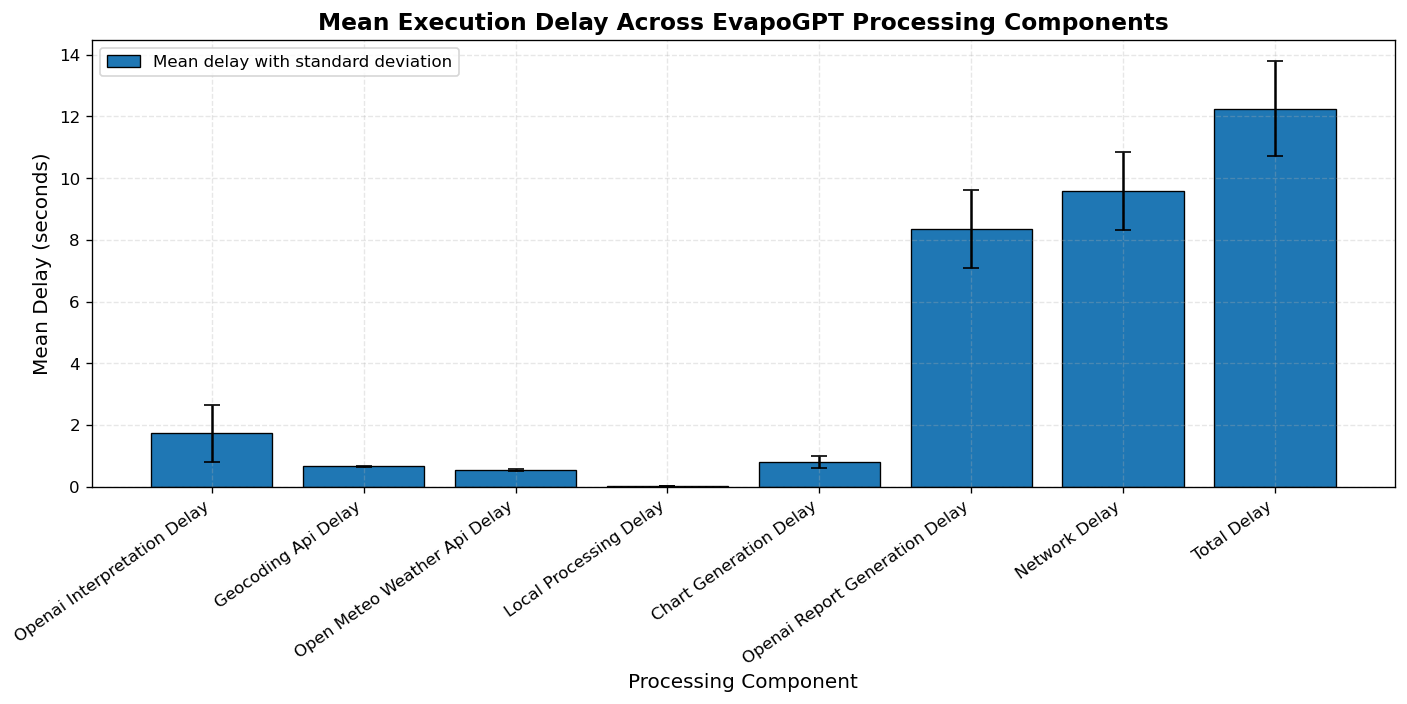

Copyable table: Mean latency summary


,Metric,mean,std,median,min,max
0,openai_interpretation_delay_sec,1.728956,0.923159,1.381447,1.144984,4.556739
1,geocoding_api_delay_sec,0.668114,0.016056,0.660758,0.647901,0.695969
2,open_meteo_weather_api_delay_sec,0.551890,0.029153,0.554835,0.524333,0.642809
3,local_processing_delay_sec,0.015885,0.002288,0.015577,0.013137,0.021288
4,chart_generation_delay_sec,0.792555,0.191895,0.681811,0.640114,1.221224
5,openai_report_generation_delay_sec,8.366120,1.262598,8.102893,6.291322,12.116391
6,network_delay_sec,9.586124,1.272648,9.334598,7.470810,13.344881
7,total_delay_sec,12.256687,1.543902,12.027428,9.470541,15.625804


Saved plot: D:\technical writing\evapogpt\publication_plots\mean_latency_comparison.png


In [12]:
summary_latency = latency_df.agg(["mean", "std", "median", "min", "max"]).T
summary_latency = summary_latency.reset_index().rename(columns={"index": "Metric"})

summary_latency["Metric_Label"] = summary_latency["Metric"].str.replace("_", " ").str.replace(" sec", "", regex=False).str.title()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    summary_latency["Metric_Label"],
    summary_latency["mean"],
    yerr=summary_latency["std"],
    capsize=5,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Mean Execution Delay Across EvapoGPT Processing Components", fontweight="bold")
plt.xlabel("Processing Component")
plt.ylabel("Mean Delay (seconds)")
plt.xticks(rotation=35, ha="right")

plt.legend(
    [bars],
    ["Mean delay with standard deviation"],
    frameon=True,
    loc="upper left"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "mean_latency_comparison.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Mean latency summary")
display(summary_latency[["Metric", "mean", "std", "median", "min", "max"]].round(6))
print("Saved plot:", plot_path)

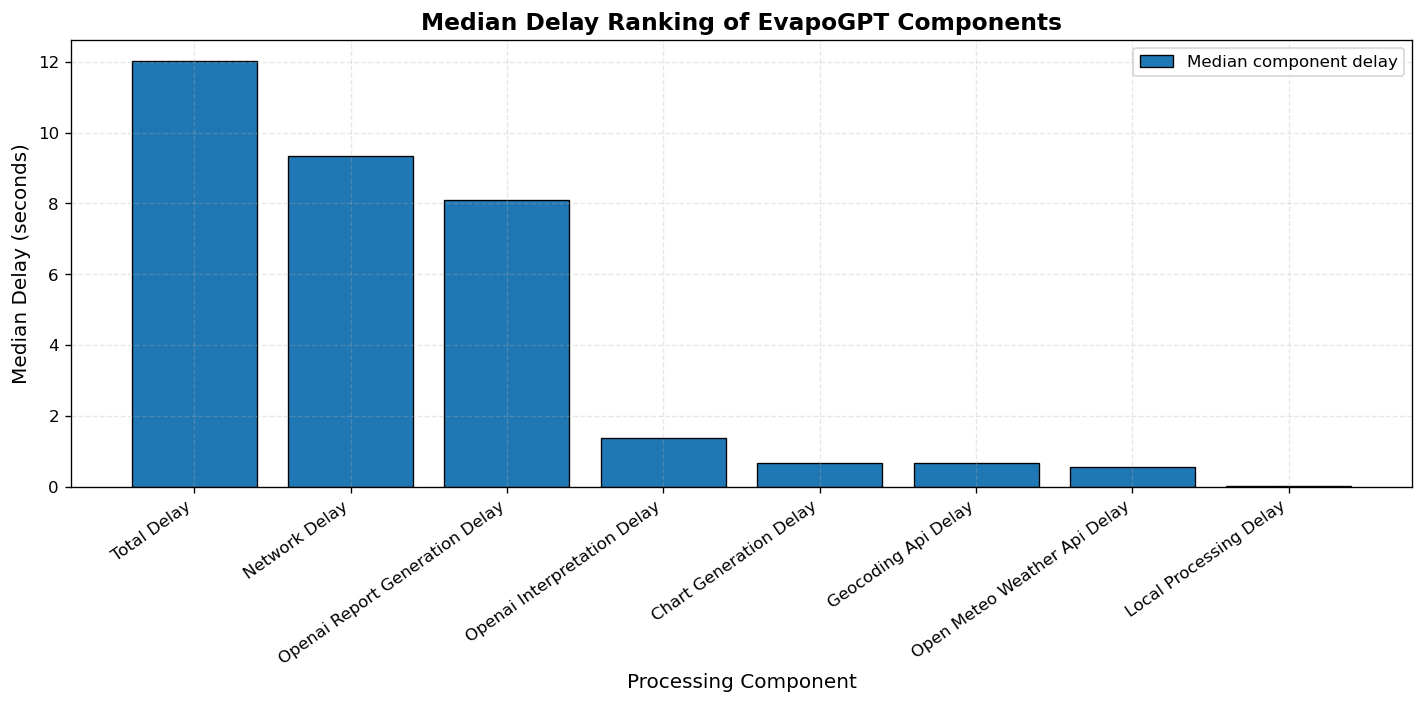

Copyable table: Median latency ranking


,Metric,Median_Delay_sec
0,total_delay_sec,12.027428
1,network_delay_sec,9.334598
2,openai_report_generation_delay_sec,8.102893
3,openai_interpretation_delay_sec,1.381447
4,chart_generation_delay_sec,0.681811
5,geocoding_api_delay_sec,0.660758
6,open_meteo_weather_api_delay_sec,0.554835
7,local_processing_delay_sec,0.015577


Saved plot: D:\technical writing\evapogpt\publication_plots\median_latency_ranking.png


In [13]:
median_latency = latency_df.median().sort_values(ascending=False).reset_index()
median_latency.columns = ["Metric", "Median_Delay_sec"]
median_latency["Metric_Label"] = median_latency["Metric"].str.replace("_", " ").str.replace(" sec", "", regex=False).str.title()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    median_latency["Metric_Label"],
    median_latency["Median_Delay_sec"],
    edgecolor="black",
    linewidth=0.8
)

plt.title("Median Delay Ranking of EvapoGPT Components", fontweight="bold")
plt.xlabel("Processing Component")
plt.ylabel("Median Delay (seconds)")
plt.xticks(rotation=35, ha="right")

plt.legend(
    [bars],
    ["Median component delay"],
    frameon=True,
    loc="upper right"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "median_latency_ranking.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Median latency ranking")
display(median_latency[["Metric", "Median_Delay_sec"]].round(6))
print("Saved plot:", plot_path)

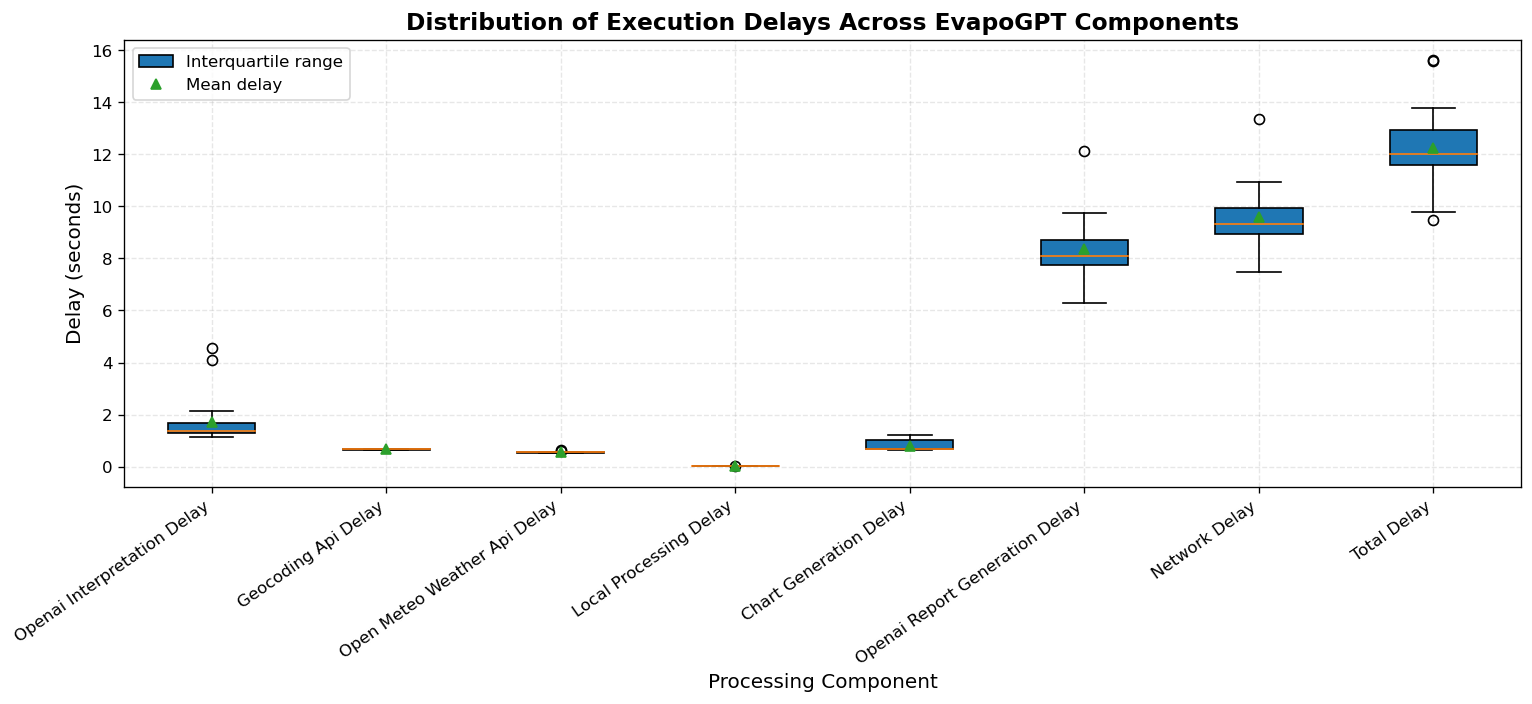

Copyable table: Descriptive statistics for latency distribution


,count,mean,std,min,25%,50%,75%,max
openai_interpretation_delay_sec,20.0,1.728956,0.923159,1.144984,1.305745,1.381447,1.676544,4.556739
geocoding_api_delay_sec,20.0,0.668114,0.016056,0.647901,0.655858,0.660758,0.685663,0.695969
open_meteo_weather_api_delay_sec,20.0,0.551890,0.029153,0.524333,0.528946,0.554835,0.557898,0.642809
local_processing_delay_sec,20.0,0.015885,0.002288,0.013137,0.013964,0.015577,0.016536,0.021288
chart_generation_delay_sec,20.0,0.792555,0.191895,0.640114,0.671162,0.681811,1.016732,1.221224
openai_report_generation_delay_sec,20.0,8.366120,1.262598,6.291322,7.731486,8.102893,8.695072,12.116391
network_delay_sec,20.0,9.586124,1.272648,7.470810,8.947161,9.334598,9.947206,13.344881
total_delay_sec,20.0,12.256687,1.543902,9.470541,11.573012,12.027428,12.949663,15.625804


Saved plot: D:\technical writing\evapogpt\publication_plots\latency_distribution_boxplot.png


In [14]:
plot_data = latency_df.dropna(how="all")

labels = [
    col.replace("_", " ").replace(" sec", "").title()
    for col in plot_data.columns
]

plt.figure(figsize=(13, 6))

box = plt.boxplot(
    [plot_data[col].dropna() for col in plot_data.columns],
    labels=labels,
    patch_artist=True,
    showmeans=True
)

plt.title("Distribution of Execution Delays Across EvapoGPT Components", fontweight="bold")
plt.xlabel("Processing Component")
plt.ylabel("Delay (seconds)")
plt.xticks(rotation=35, ha="right")

plt.legend(
    [box["boxes"][0], box["means"][0]],
    ["Interquartile range", "Mean delay"],
    frameon=True,
    loc="upper left"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "latency_distribution_boxplot.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Descriptive statistics for latency distribution")
display(latency_df.describe().T.round(6))
print("Saved plot:", plot_path)

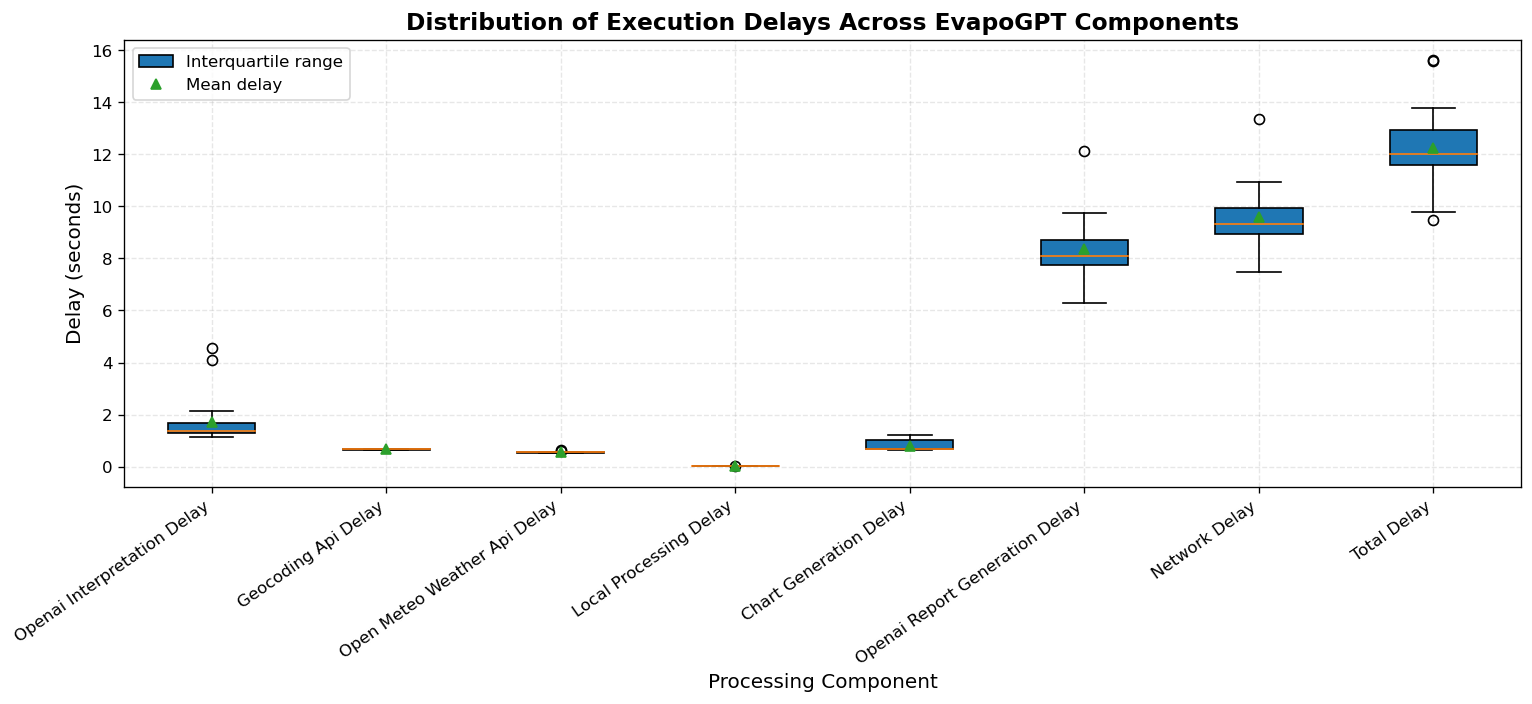

Copyable table: Descriptive statistics for latency distribution


,count,mean,std,min,25%,50%,75%,max
openai_interpretation_delay_sec,20.0,1.728956,0.923159,1.144984,1.305745,1.381447,1.676544,4.556739
geocoding_api_delay_sec,20.0,0.668114,0.016056,0.647901,0.655858,0.660758,0.685663,0.695969
open_meteo_weather_api_delay_sec,20.0,0.551890,0.029153,0.524333,0.528946,0.554835,0.557898,0.642809
local_processing_delay_sec,20.0,0.015885,0.002288,0.013137,0.013964,0.015577,0.016536,0.021288
chart_generation_delay_sec,20.0,0.792555,0.191895,0.640114,0.671162,0.681811,1.016732,1.221224
openai_report_generation_delay_sec,20.0,8.366120,1.262598,6.291322,7.731486,8.102893,8.695072,12.116391
network_delay_sec,20.0,9.586124,1.272648,7.470810,8.947161,9.334598,9.947206,13.344881
total_delay_sec,20.0,12.256687,1.543902,9.470541,11.573012,12.027428,12.949663,15.625804


Saved plot: D:\technical writing\evapogpt\publication_plots\latency_distribution_boxplot.png


In [15]:
plot_data = latency_df.dropna(how="all")

labels = [
    col.replace("_", " ").replace(" sec", "").title()
    for col in plot_data.columns
]

plt.figure(figsize=(13, 6))

box = plt.boxplot(
    [plot_data[col].dropna() for col in plot_data.columns],
    labels=labels,
    patch_artist=True,
    showmeans=True
)

plt.title("Distribution of Execution Delays Across EvapoGPT Components", fontweight="bold")
plt.xlabel("Processing Component")
plt.ylabel("Delay (seconds)")
plt.xticks(rotation=35, ha="right")

plt.legend(
    [box["boxes"][0], box["means"][0]],
    ["Interquartile range", "Mean delay"],
    frameon=True,
    loc="upper left"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "latency_distribution_boxplot.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Descriptive statistics for latency distribution")
display(latency_df.describe().T.round(6))
print("Saved plot:", plot_path)

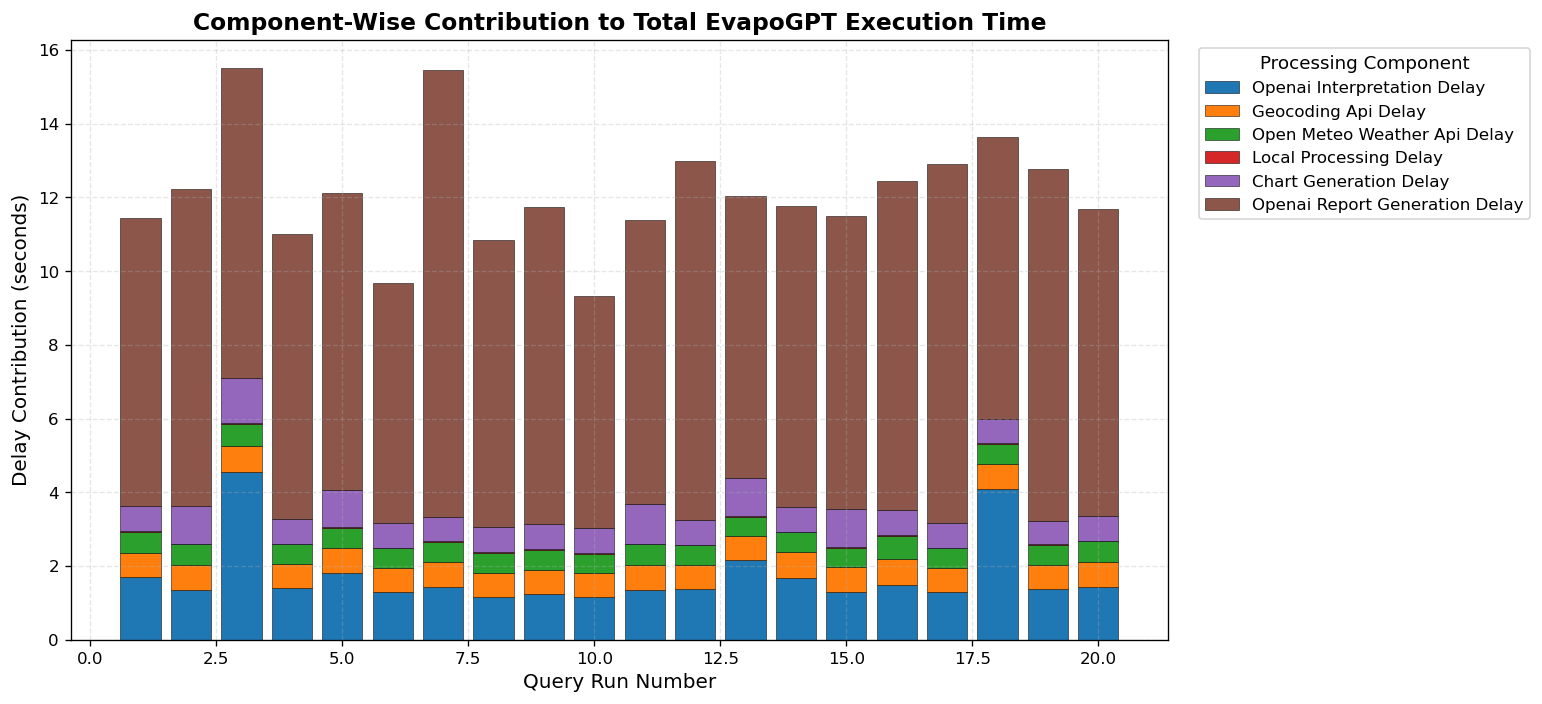

Copyable table: Component-wise delay contribution


,Run_Number,openai_interpretation_delay_sec,geocoding_api_delay_sec,open_meteo_weather_api_delay_sec,local_processing_delay_sec,chart_generation_delay_sec,openai_report_generation_delay_sec
0,1,1.696788,0.663650,0.558913,0.016303,0.682361,7.823079
1,2,1.345182,0.686162,0.559342,0.016516,1.027464,8.593862
2,3,4.556739,0.690546,0.606550,0.013377,1.221224,8.420457
3,4,1.396726,0.657716,0.530499,0.019923,0.665394,7.740364
4,5,1.821278,0.658690,0.555579,0.021288,1.013155,8.054685
5,6,1.303969,0.647901,0.524977,0.013137,0.684015,6.499332
6,7,1.422509,0.672808,0.555682,0.016378,0.673649,12.116391
7,8,1.150043,0.655972,0.555923,0.013986,0.671157,7.792894
8,9,1.252091,0.651250,0.529009,0.016595,0.681261,8.615758
9,10,1.144984,0.655156,0.524333,0.014658,0.693248,6.291322


Saved plot: D:\technical writing\evapogpt\publication_plots\stacked_latency_contribution.png


In [16]:
component_cols = [
    "openai_interpretation_delay_sec",
    "geocoding_api_delay_sec",
    "open_meteo_weather_api_delay_sec",
    "local_processing_delay_sec",
    "chart_generation_delay_sec",
    "openai_report_generation_delay_sec"
]

component_cols = [col for col in component_cols if col in latency_df.columns]

component_df = latency_df[component_cols].copy()
component_df = component_df.fillna(0)

run_index = np.arange(1, len(component_df) + 1)

plt.figure(figsize=(13, 6))

bottom = np.zeros(len(component_df))

for col in component_cols:
    plt.bar(
        run_index,
        component_df[col],
        bottom=bottom,
        label=col.replace("_", " ").replace(" sec", "").title(),
        edgecolor="black",
        linewidth=0.3
    )
    bottom += component_df[col].values

plt.title("Component-Wise Contribution to Total EvapoGPT Execution Time", fontweight="bold")
plt.xlabel("Query Run Number")
plt.ylabel("Delay Contribution (seconds)")

plt.legend(
    title="Processing Component",
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "stacked_latency_contribution.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Component-wise delay contribution")
component_table = component_df.copy()
component_table.insert(0, "Run_Number", run_index)
display(component_table.round(6))
print("Saved plot:", plot_path)

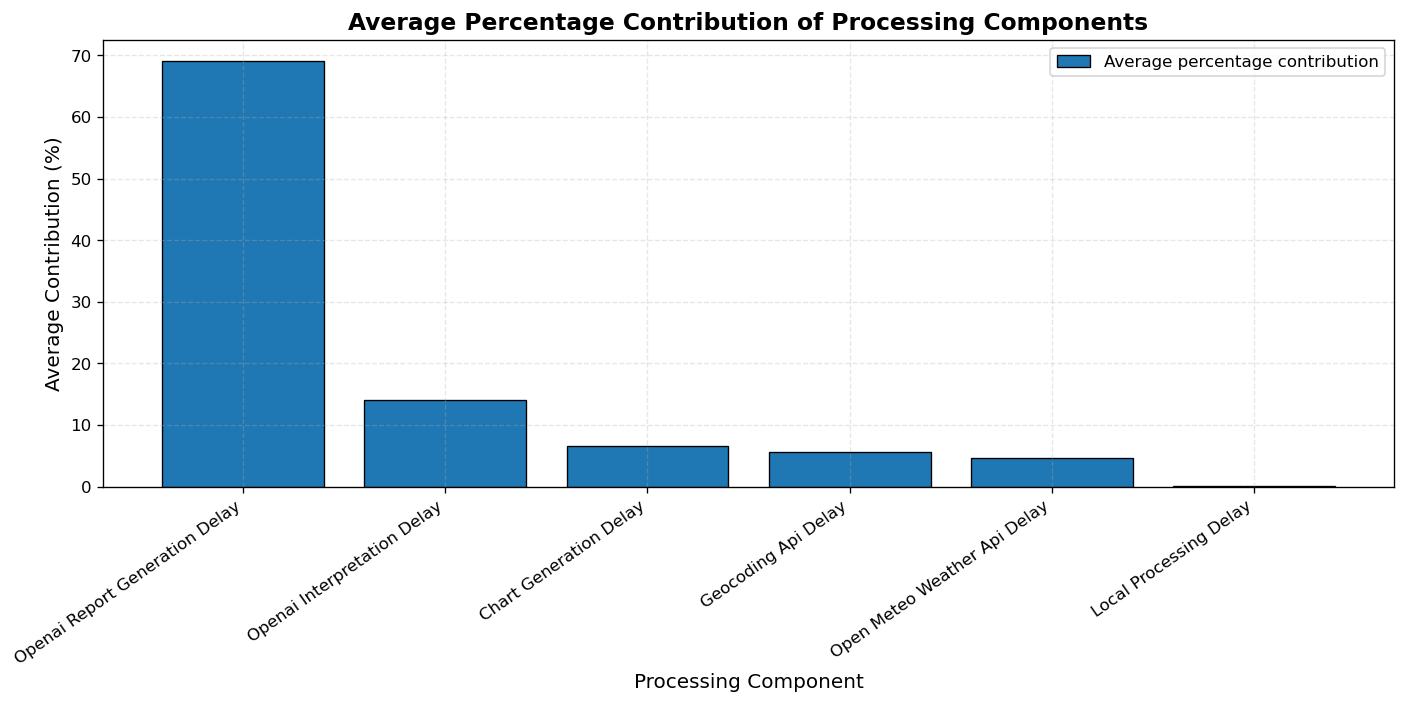

Copyable table: Average percentage contribution


,Metric,Mean_Percentage_Contribution
0,openai_report_generation_delay_sec,69.091063
1,openai_interpretation_delay_sec,13.983888
2,chart_generation_delay_sec,6.595895
3,geocoding_api_delay_sec,5.587840
4,open_meteo_weather_api_delay_sec,4.608258
5,local_processing_delay_sec,0.133057


Saved plot: D:\technical writing\evapogpt\publication_plots\average_percentage_latency_contribution.png


In [17]:
component_percent = component_df.div(component_df.sum(axis=1).replace(0, np.nan), axis=0) * 100
mean_percent = component_percent.mean().sort_values(ascending=False).reset_index()
mean_percent.columns = ["Metric", "Mean_Percentage_Contribution"]
mean_percent["Metric_Label"] = mean_percent["Metric"].str.replace("_", " ").str.replace(" sec", "", regex=False).str.title()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    mean_percent["Metric_Label"],
    mean_percent["Mean_Percentage_Contribution"],
    edgecolor="black",
    linewidth=0.8
)

plt.title("Average Percentage Contribution of Processing Components", fontweight="bold")
plt.xlabel("Processing Component")
plt.ylabel("Average Contribution (%)")
plt.xticks(rotation=35, ha="right")

plt.legend(
    [bars],
    ["Average percentage contribution"],
    frameon=True,
    loc="upper right"
)

plt.tight_layout()

plot_path = os.path.join(output_dir, "average_percentage_latency_contribution.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Average percentage contribution")
display(mean_percent[["Metric", "Mean_Percentage_Contribution"]].round(6))
print("Saved plot:", plot_path)

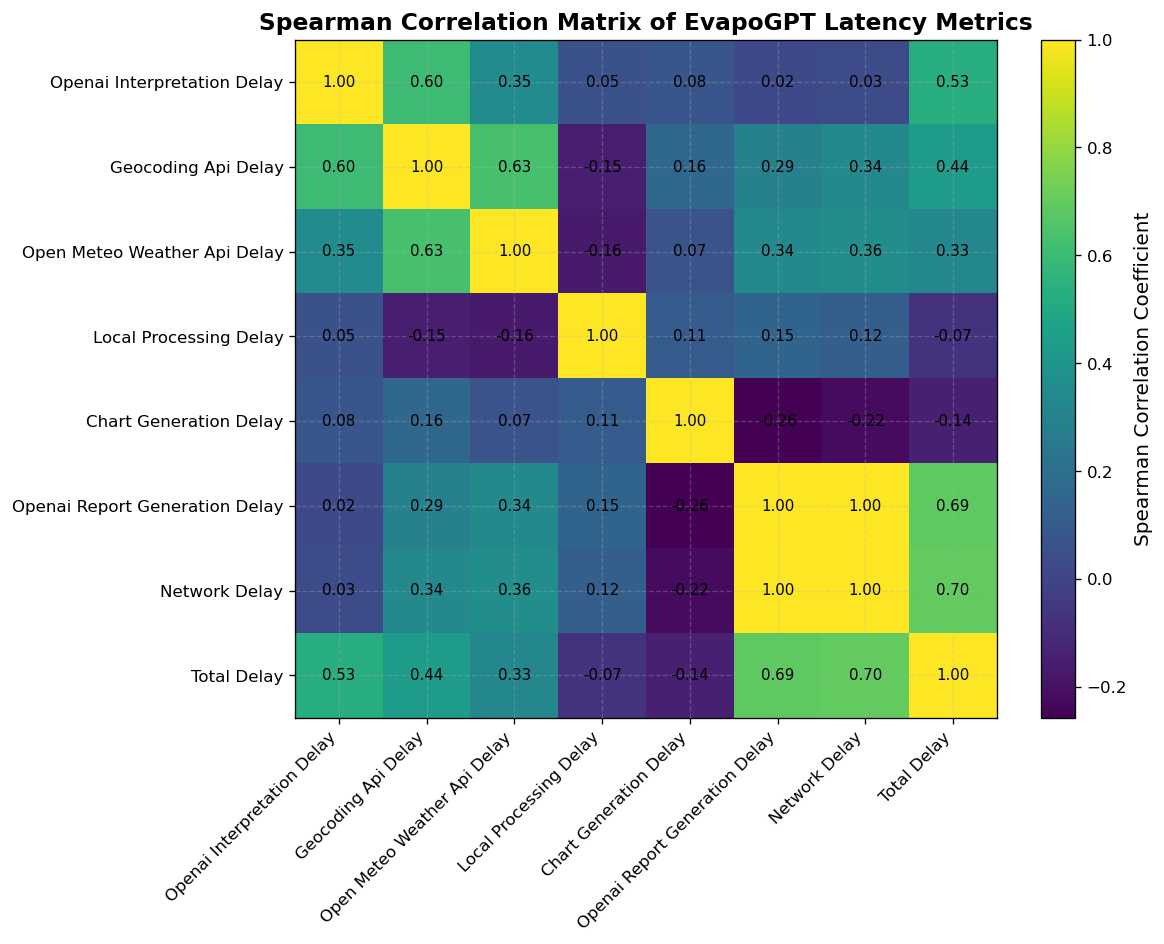

Copyable table: Spearman correlation matrix


,openai_interpretation_delay_sec,geocoding_api_delay_sec,open_meteo_weather_api_delay_sec,local_processing_delay_sec,chart_generation_delay_sec,openai_report_generation_delay_sec,network_delay_sec,total_delay_sec
openai_interpretation_delay_sec,1.0000,0.6045,0.3504,0.0541,0.0782,0.0211,0.0316,0.5278
geocoding_api_delay_sec,0.6045,1.0000,0.6346,-0.1504,0.1624,0.2917,0.3353,0.4361
open_meteo_weather_api_delay_sec,0.3504,0.6346,1.0000,-0.1639,0.0662,0.3368,0.3639,0.3263
local_processing_delay_sec,0.0541,-0.1504,-0.1639,1.0000,0.1068,0.1489,0.1248,-0.0722
chart_generation_delay_sec,0.0782,0.1624,0.0662,0.1068,1.0000,-0.2571,-0.2226,-0.1444
openai_report_generation_delay_sec,0.0211,0.2917,0.3368,0.1489,-0.2571,1.0000,0.9955,0.6887
network_delay_sec,0.0316,0.3353,0.3639,0.1248,-0.2226,0.9955,1.0000,0.6977
total_delay_sec,0.5278,0.4361,0.3263,-0.0722,-0.1444,0.6887,0.6977,1.0000


Saved plot: D:\technical writing\evapogpt\publication_plots\spearman_latency_correlation_heatmap.png


In [18]:
corr_df = latency_df.corr(method="spearman")

plt.figure(figsize=(10, 8))

im = plt.imshow(corr_df, aspect="auto")

plt.colorbar(im, label="Spearman Correlation Coefficient")

plt.xticks(
    ticks=np.arange(len(corr_df.columns)),
    labels=[col.replace("_", " ").replace(" sec", "").title() for col in corr_df.columns],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_df.index)),
    labels=[idx.replace("_", " ").replace(" sec", "").title() for idx in corr_df.index]
)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        value = corr_df.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)

plt.title("Spearman Correlation Matrix of EvapoGPT Latency Metrics", fontweight="bold")

plt.tight_layout()

plot_path = os.path.join(output_dir, "spearman_latency_correlation_heatmap.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Copyable table: Spearman correlation matrix")
display(corr_df.round(4))
print("Saved plot:", plot_path)

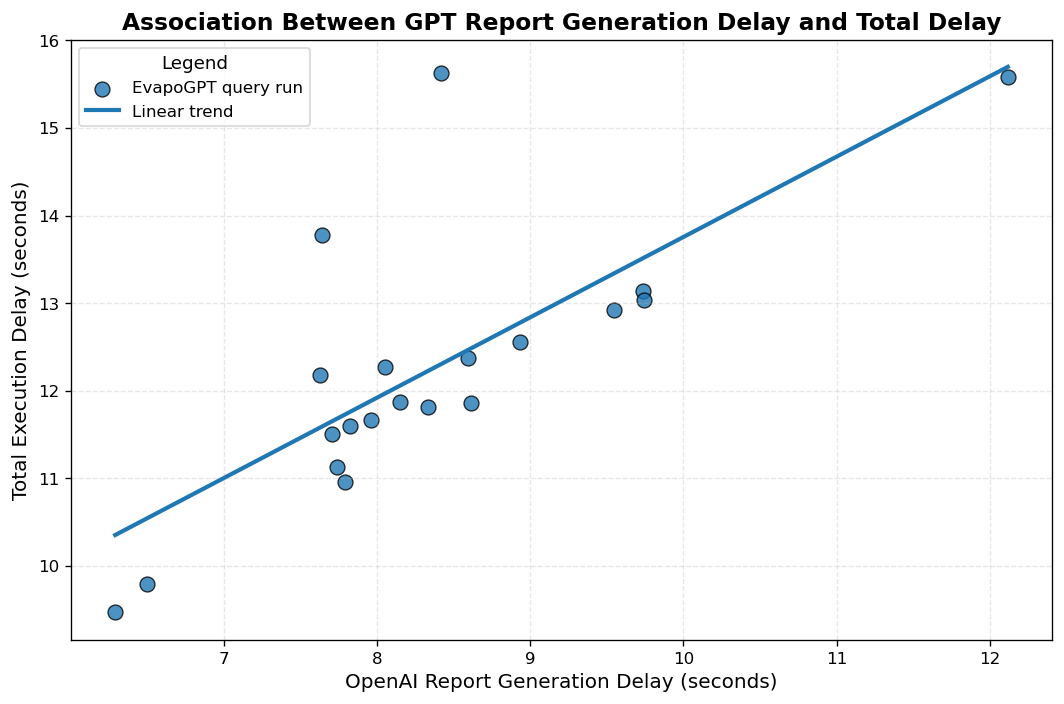

Copyable table: OpenAI report delay vs total delay


,Run_Number,openai_report_generation_delay_sec,total_delay_sec
0,1,7.823079,11.594962
1,2,8.593862,12.371858
2,3,8.420457,15.625804
3,4,7.740364,11.135010
4,5,8.054685,12.276466
5,6,6.499332,9.789123
6,7,12.116391,15.583430
7,8,7.792894,10.959086
8,9,8.615758,11.861624
9,10,6.291322,9.470541


Saved plot: D:\technical writing\evapogpt\publication_plots\openai_report_delay_vs_total_delay.png


In [19]:
x_col = "openai_report_generation_delay_sec"
y_col = "total_delay_sec"

if x_col in latency_df.columns and y_col in latency_df.columns:

    x = latency_df[x_col]
    y = latency_df[y_col]

    plt.figure(figsize=(9, 6))

    plt.scatter(
        x,
        y,
        s=80,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.80,
        label="EvapoGPT query run"
    )

    if x.notna().sum() >= 2:
        coef = np.polyfit(x.dropna(), y.loc[x.dropna().index], 1)
        trend_x = np.linspace(x.min(), x.max(), 100)
        trend_y = coef[0] * trend_x + coef[1]

        plt.plot(
            trend_x,
            trend_y,
            linewidth=2.5,
            label="Linear trend"
        )

    plt.title("Association Between GPT Report Generation Delay and Total Delay", fontweight="bold")
    plt.xlabel("OpenAI Report Generation Delay (seconds)")
    plt.ylabel("Total Execution Delay (seconds)")

    plt.legend(
        title="Legend",
        frameon=True,
        loc="best"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "openai_report_delay_vs_total_delay.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    scatter_table = df[[x_col, y_col]].copy()
    scatter_table.insert(0, "Run_Number", np.arange(1, len(scatter_table) + 1))

    print("Copyable table: OpenAI report delay vs total delay")
    display(scatter_table.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

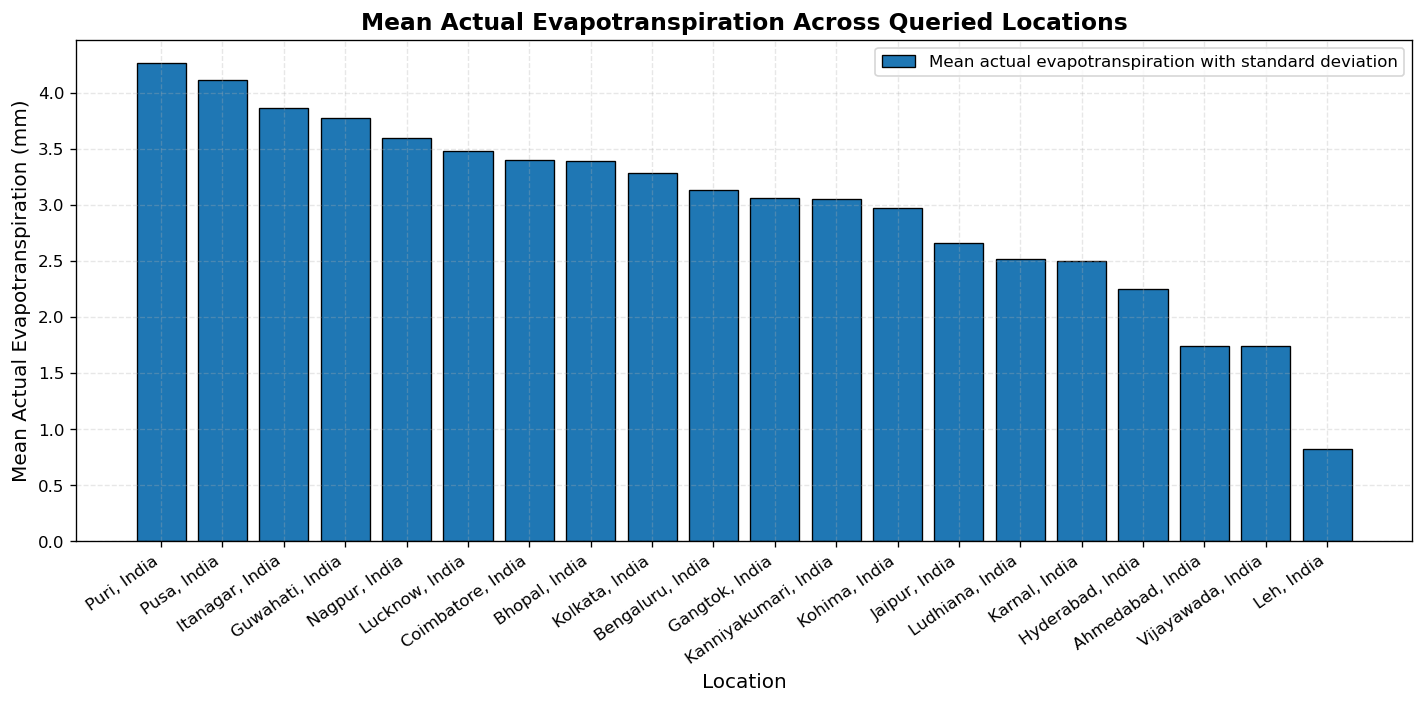

Copyable table: Actual evapotranspiration by location


,parsed_place,mean,std,median,count
17,"Puri, India",4.26,NaN,4.26,1
18,"Pusa, India",4.11,NaN,4.11,1
7,"Itanagar, India",3.86,NaN,3.86,1
5,"Guwahati, India",3.77,NaN,3.77,1
16,"Nagpur, India",3.60,NaN,3.60,1
14,"Lucknow, India",3.48,NaN,3.48,1
3,"Coimbatore, India",3.40,NaN,3.40,1
2,"Bhopal, India",3.39,NaN,3.39,1
12,"Kolkata, India",3.28,NaN,3.28,1
1,"Bengaluru, India",3.13,NaN,3.13,1


Saved plot: D:\technical writing\evapogpt\publication_plots\mean_actual_evapotranspiration_by_location.png


In [20]:
et_col = "actual_evapotranspiration_total_mm"
place_col = "parsed_place"

if et_col in df.columns and place_col in df.columns:

    et_place = df[[place_col, et_col]].copy()
    et_place[et_col] = pd.to_numeric(et_place[et_col], errors="coerce")

    et_summary = (
        et_place
        .groupby(place_col, dropna=False)[et_col]
        .agg(["mean", "std", "median", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        et_summary[place_col].astype(str),
        et_summary["mean"],
        yerr=et_summary["std"],
        capsize=5,
        edgecolor="black",
        linewidth=0.8
    )

    plt.title("Mean Actual Evapotranspiration Across Queried Locations", fontweight="bold")
    plt.xlabel("Location")
    plt.ylabel("Mean Actual Evapotranspiration (mm)")
    plt.xticks(rotation=35, ha="right")

    plt.legend(
        [bars],
        ["Mean actual evapotranspiration with standard deviation"],
        frameon=True,
        loc="upper right"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "mean_actual_evapotranspiration_by_location.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Copyable table: Actual evapotranspiration by location")
    display(et_summary.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

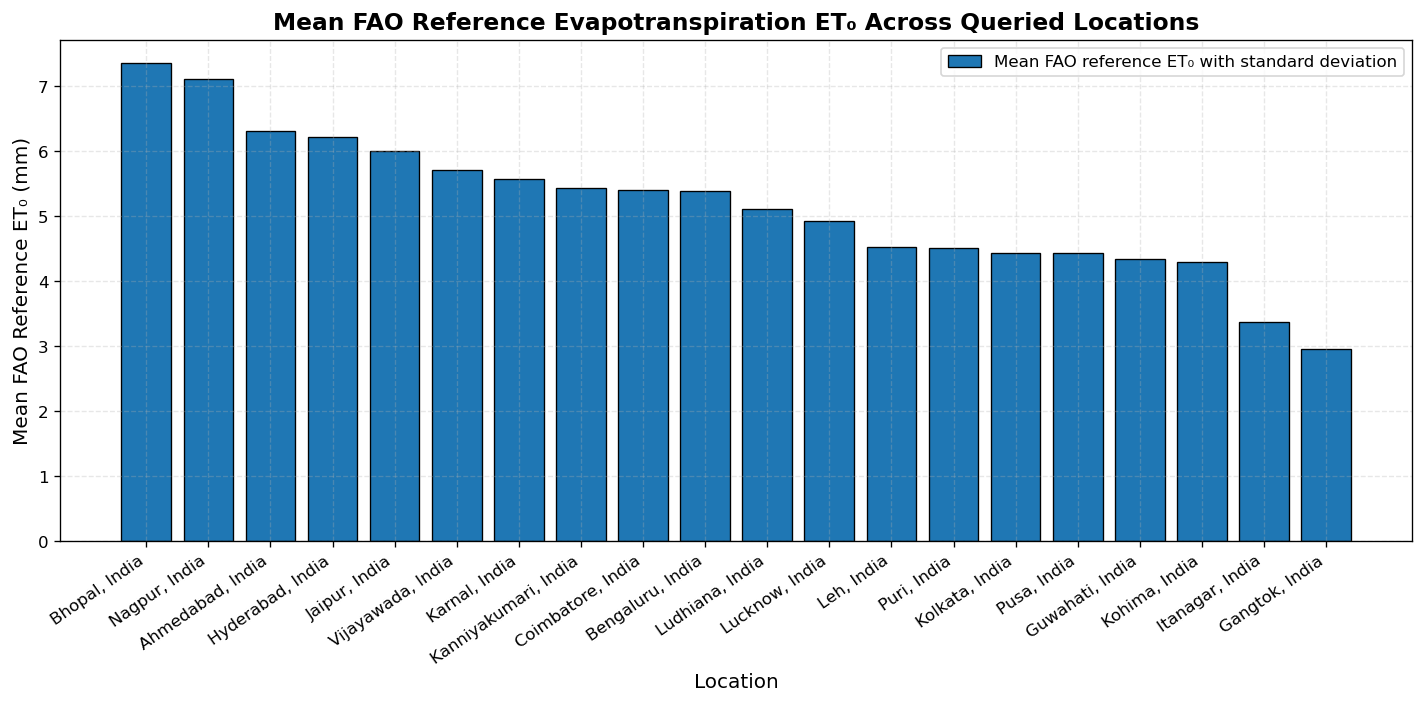

Copyable table: FAO reference ET0 by location


,parsed_place,mean,std,median,count
2,"Bhopal, India",7.35,NaN,7.35,1
16,"Nagpur, India",7.11,NaN,7.11,1
0,"Ahmedabad, India",6.31,NaN,6.31,1
6,"Hyderabad, India",6.22,NaN,6.22,1
8,"Jaipur, India",6.00,NaN,6.00,1
19,"Vijayawada, India",5.71,NaN,5.71,1
10,"Karnal, India",5.57,NaN,5.57,1
9,"Kanniyakumari, India",5.43,NaN,5.43,1
3,"Coimbatore, India",5.40,NaN,5.40,1
1,"Bengaluru, India",5.39,NaN,5.39,1


Saved plot: D:\technical writing\evapogpt\publication_plots\mean_et0_by_location.png


In [21]:
et0_col = "et0_fao_total_mm_from_hourly"
place_col = "parsed_place"

if et0_col in df.columns and place_col in df.columns:

    et0_place = df[[place_col, et0_col]].copy()
    et0_place[et0_col] = pd.to_numeric(et0_place[et0_col], errors="coerce")

    et0_summary = (
        et0_place
        .groupby(place_col, dropna=False)[et0_col]
        .agg(["mean", "std", "median", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        et0_summary[place_col].astype(str),
        et0_summary["mean"],
        yerr=et0_summary["std"],
        capsize=5,
        edgecolor="black",
        linewidth=0.8
    )

    plt.title("Mean FAO Reference Evapotranspiration ET₀ Across Queried Locations", fontweight="bold")
    plt.xlabel("Location")
    plt.ylabel("Mean FAO Reference ET₀ (mm)")
    plt.xticks(rotation=35, ha="right")

    plt.legend(
        [bars],
        ["Mean FAO reference ET₀ with standard deviation"],
        frameon=True,
        loc="upper right"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "mean_et0_by_location.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Copyable table: FAO reference ET0 by location")
    display(et0_summary.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

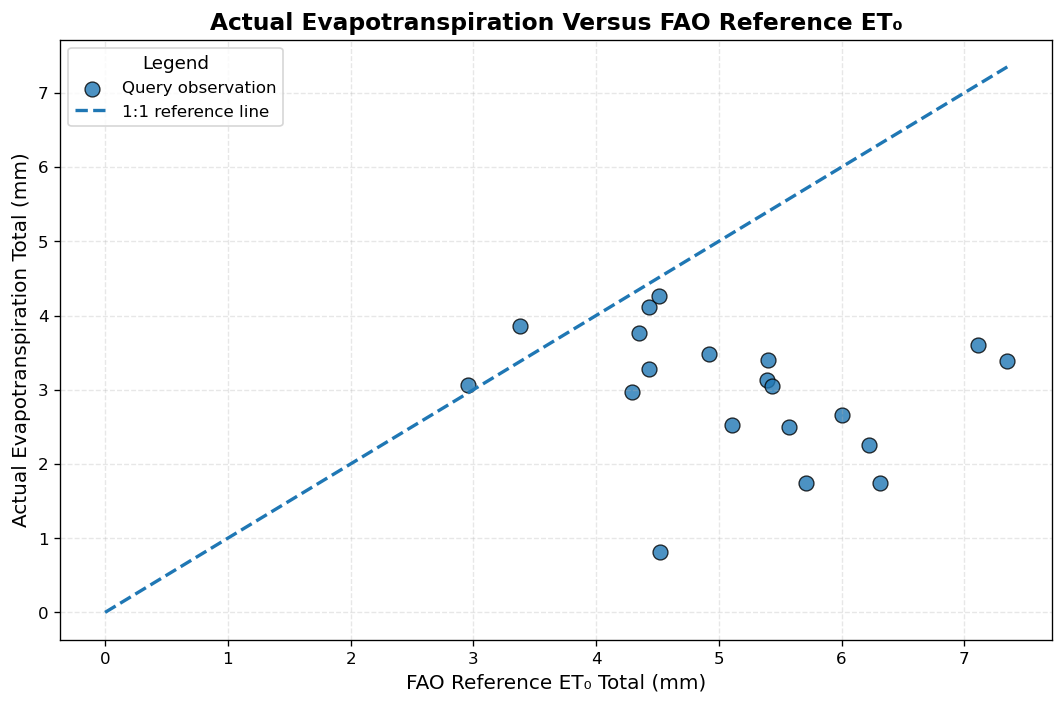

Copyable table: Actual ET and ET0 comparison


,actual_evapotranspiration_total_mm,et0_fao_total_mm_from_hourly
0,3.06,2.96
1,3.28,4.43
2,4.11,4.43
3,4.26,4.51
4,2.52,5.11
5,2.50,5.57
6,3.48,4.92
7,3.77,4.35
8,2.66,6.00
9,1.74,6.31


Saved plot: D:\technical writing\evapogpt\publication_plots\actual_et_vs_et0_scatter.png


In [22]:
actual_col = "actual_evapotranspiration_total_mm"
et0_col = "et0_fao_total_mm_from_hourly"

if actual_col in df.columns and et0_col in df.columns:

    compare_df = df[[actual_col, et0_col]].copy()
    compare_df[actual_col] = pd.to_numeric(compare_df[actual_col], errors="coerce")
    compare_df[et0_col] = pd.to_numeric(compare_df[et0_col], errors="coerce")
    compare_df = compare_df.dropna()

    plt.figure(figsize=(9, 6))

    plt.scatter(
        compare_df[et0_col],
        compare_df[actual_col],
        s=80,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.80,
        label="Query observation"
    )

    max_value = max(compare_df[actual_col].max(), compare_df[et0_col].max())

    plt.plot(
        [0, max_value],
        [0, max_value],
        linestyle="--",
        linewidth=2,
        label="1:1 reference line"
    )

    plt.title("Actual Evapotranspiration Versus FAO Reference ET₀", fontweight="bold")
    plt.xlabel("FAO Reference ET₀ Total (mm)")
    plt.ylabel("Actual Evapotranspiration Total (mm)")

    plt.legend(
        title="Legend",
        frameon=True,
        loc="best"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "actual_et_vs_et0_scatter.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Copyable table: Actual ET and ET0 comparison")
    display(compare_df.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

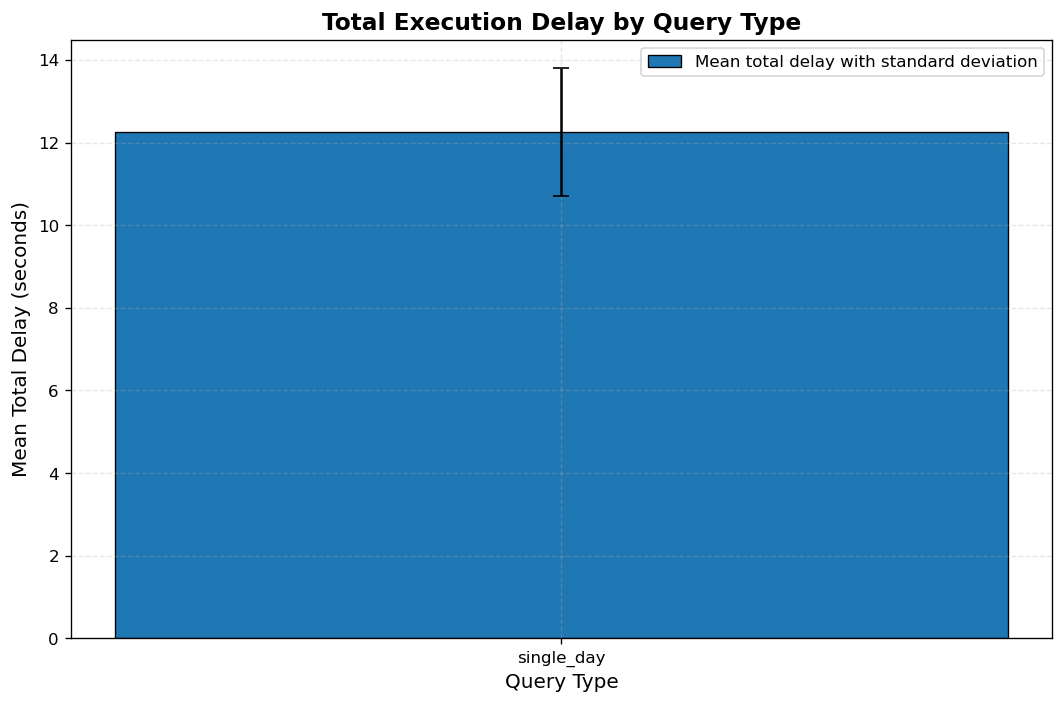

Copyable table: Total delay by query type


,query_type,mean,std,median,count
0,single_day,12.256687,1.543902,12.027428,20


Saved plot: D:\technical writing\evapogpt\publication_plots\total_delay_by_query_type.png


In [23]:
query_type_col = "query_type"
delay_col = "total_delay_sec"

if query_type_col in df.columns and delay_col in df.columns:

    query_delay = df[[query_type_col, delay_col]].copy()
    query_delay[delay_col] = pd.to_numeric(query_delay[delay_col], errors="coerce")

    query_summary = (
        query_delay
        .groupby(query_type_col, dropna=False)[delay_col]
        .agg(["mean", "std", "median", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        query_summary[query_type_col].astype(str),
        query_summary["mean"],
        yerr=query_summary["std"],
        capsize=5,
        edgecolor="black",
        linewidth=0.8
    )

    plt.title("Total Execution Delay by Query Type", fontweight="bold")
    plt.xlabel("Query Type")
    plt.ylabel("Mean Total Delay (seconds)")

    plt.legend(
        [bars],
        ["Mean total delay with standard deviation"],
        frameon=True,
        loc="upper right"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "total_delay_by_query_type.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Copyable table: Total delay by query type")
    display(query_summary.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

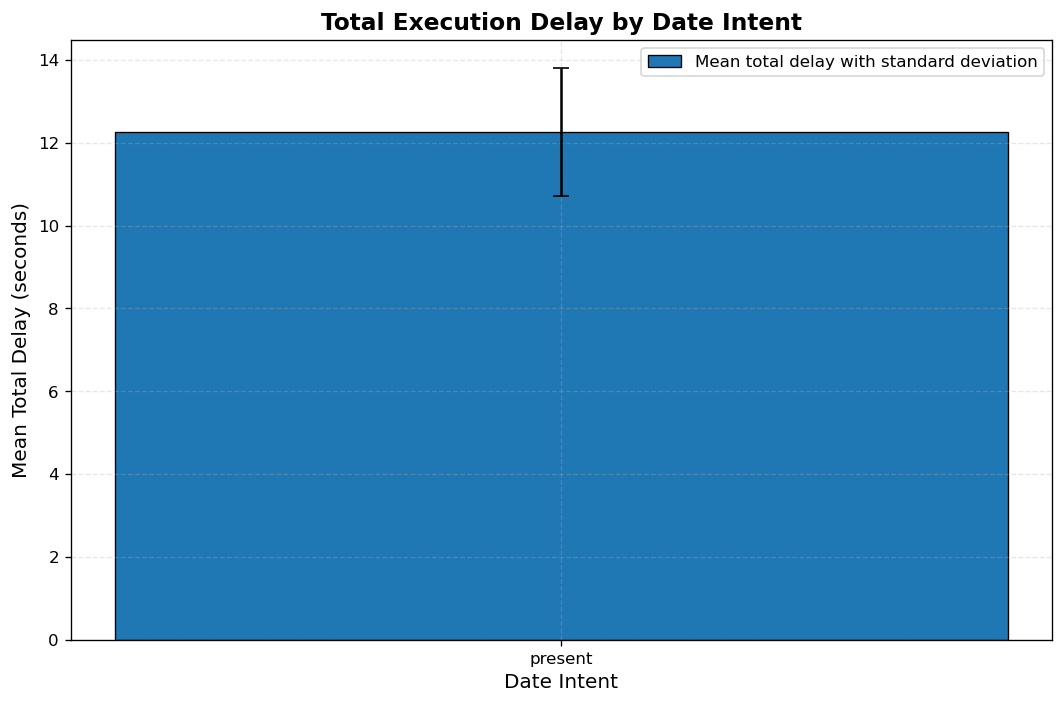

Copyable table: Total delay by date intent


,date_intent,mean,std,median,count
0,present,12.256687,1.543902,12.027428,20


Saved plot: D:\technical writing\evapogpt\publication_plots\total_delay_by_date_intent.png


In [24]:
date_intent_col = "date_intent"
delay_col = "total_delay_sec"

if date_intent_col in df.columns and delay_col in df.columns:

    intent_delay = df[[date_intent_col, delay_col]].copy()
    intent_delay[delay_col] = pd.to_numeric(intent_delay[delay_col], errors="coerce")

    intent_summary = (
        intent_delay
        .groupby(date_intent_col, dropna=False)[delay_col]
        .agg(["mean", "std", "median", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        intent_summary[date_intent_col].astype(str),
        intent_summary["mean"],
        yerr=intent_summary["std"],
        capsize=5,
        edgecolor="black",
        linewidth=0.8
    )

    plt.title("Total Execution Delay by Date Intent", fontweight="bold")
    plt.xlabel("Date Intent")
    plt.ylabel("Mean Total Delay (seconds)")

    plt.legend(
        [bars],
        ["Mean total delay with standard deviation"],
        frameon=True,
        loc="upper right"
    )

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "total_delay_by_date_intent.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Copyable table: Total delay by date intent")
    display(intent_summary.round(6))
    print("Saved plot:", plot_path)
else:
    print("Required columns not found.")

In [25]:
from scipy.stats import shapiro

normality_results = []

for col in available_latency_cols:
    values = latency_df[col].dropna()

    if len(values) >= 3:
        stat, p_value = shapiro(values)
        normality_results.append({
            "Metric": col,
            "Shapiro_Wilk_Statistic": stat,
            "p_value": p_value,
            "Normality_Interpretation_alpha_0_05": "Approximately normal" if p_value >= 0.05 else "Non-normal"
        })

normality_df = pd.DataFrame(normality_results)

print("Shapiro-Wilk normality test results")
display(normality_df.round(6))

Shapiro-Wilk normality test results


,Metric,Shapiro_Wilk_Statistic,p_value,Normality_Interpretation_alpha_0_05
0,openai_interpretation_delay_sec,0.572045,0.000002,Non-normal
1,geocoding_api_delay_sec,0.855009,0.006474,Non-normal
2,open_meteo_weather_api_delay_sec,0.754746,0.000197,Non-normal
3,local_processing_delay_sec,0.913311,0.073724,Approximately normal
4,chart_generation_delay_sec,0.690683,0.000030,Non-normal
5,openai_report_generation_delay_sec,0.893435,0.031116,Non-normal
6,network_delay_sec,0.898866,0.039270,Non-normal
7,total_delay_sec,0.933132,0.177369,Approximately normal


In [26]:
from scipy.stats import friedmanchisquare

friedman_cols = [
    "openai_interpretation_delay_sec",
    "geocoding_api_delay_sec",
    "open_meteo_weather_api_delay_sec",
    "local_processing_delay_sec",
    "chart_generation_delay_sec",
    "openai_report_generation_delay_sec"
]

friedman_cols = [col for col in friedman_cols if col in latency_df.columns]

friedman_data = latency_df[friedman_cols].dropna()

if len(friedman_cols) >= 3 and len(friedman_data) >= 2:
    stat, p_value = friedmanchisquare(
        *[friedman_data[col] for col in friedman_cols]
    )

    friedman_result = pd.DataFrame({
        "Test": ["Friedman test"],
        "Statistic": [stat],
        "p_value": [p_value],
        "Interpretation_alpha_0_05": [
            "Significant difference among latency components" if p_value < 0.05
            else "No significant difference among latency components"
        ]
    })

    display(friedman_result.round(6))
else:
    print("Insufficient data for Friedman test.")

,Test,Statistic,p_value,Interpretation_alpha_0_05
0,Friedman test,97.857143,0.0,Significant difference among latency components


In [27]:
from scipy.stats import spearmanr

target_col = "total_delay_sec"

correlation_results = []

if target_col in latency_df.columns:

    for col in available_latency_cols:
        if col != target_col:
            temp = latency_df[[col, target_col]].dropna()

            if len(temp) >= 3:
                rho, p_value = spearmanr(temp[col], temp[target_col])

                correlation_results.append({
                    "Metric": col,
                    "Target": target_col,
                    "Spearman_rho": rho,
                    "p_value": p_value,
                    "Interpretation_alpha_0_05": "Significant monotonic association" if p_value < 0.05 else "Not significant"
                })

correlation_result_df = pd.DataFrame(correlation_results)

print("Spearman correlation with total execution delay")
display(correlation_result_df.round(6))

Spearman correlation with total execution delay


,Metric,Target,Spearman_rho,p_value,Interpretation_alpha_0_05
0,openai_interpretation_delay_sec,total_delay_sec,0.527820,0.016759,Significant monotonic association
1,geocoding_api_delay_sec,total_delay_sec,0.436090,0.054584,Not significant
2,open_meteo_weather_api_delay_sec,total_delay_sec,0.326316,0.160275,Not significant
3,local_processing_delay_sec,total_delay_sec,-0.072180,0.762339,Not significant
4,chart_generation_delay_sec,total_delay_sec,-0.144361,0.543701,Not significant
5,openai_report_generation_delay_sec,total_delay_sec,0.688722,0.000785,Significant monotonic association
6,network_delay_sec,total_delay_sec,0.697744,0.000625,Significant monotonic association
